# EDA — Nettoyage, feature engineering & exploration visuelle (V6.0 — recadrage éligibilité/produit)

Version qui aligne ce notebook sur le recadrage du problème (cf. `GUIDE_MAITRE.md`, section 0 et
6.4ter, et les commentaires de `build_dataset_final.py`) : ne détenir aucun des 3 produits
d'épargne est une **4ᵉ classe** à part entière ("aucun produit"), pas une cible inconnue à
scorer. `build_dataset_final.py` écrit donc désormais **deux** jeux de données distincts au lieu
d'un seul :
- `dataset_eligibilite` — toute la population, cible = `label_eligibilite` (0/1)
- `dataset_produit` — sous-ensemble éligible uniquement, cible = `label_nom`/`label_code`

**⚠️ Oubli identifié et corrigé (à mentionner dans le rapport)** : les versions précédentes de ce
notebook lisaient un seul `dataset_train_produits` et traitaient l'absence de produit comme une
population `dataset_a_scorer` à part — ce cadrage était erroné (voir section 0 du guide). Cette
version lit indifféremment l'un des deux nouveaux jeux de données via le paramètre `DATASET_CIBLE`
(section 0 ci-dessous) et **doit être exécutée une fois par dataset** (deux passes complètes,
chacune avec ses propres statistiques de nettoyage — bornes IQR, imputers — car les deux
populations n'ont pas la même distribution).

**Corrections apportées dans cette version par rapport à la V5.0 :**
- **Recadrage éligibilité/produit** : notebook paramétré par `DATASET_CIBLE` (`"eligibilite"` ou
  `"produit"`), avec un vrai garde-fou anti-fuite : `label_nom`/`label_code` sont retirés des
  features avant tout traitement quand on travaille sur `dataset_eligibilite` (ils ne sont
  non-nuls que pour les clients éligibles — les garder équivaudrait à donner la réponse au
  modèle), et `label_eligibilite` est retiré quand on travaille sur `dataset_produit` (il y vaut
  1 partout par construction, donc sans aucune information).
- **Bug corrigé** : `anciennete_digitale_jours` et `recence_gab_jours` sont **déjà calculés** dans
  `build_dataset_final.py`, par rapport à une `DATE_REFERENCE` fixe (pas la date du jour). Ce
  notebook les recalculait pourtant une seconde fois avec `F.current_date()` avant même
  l'Imputer — ce qui écrasait silencieusement la valeur correcte par une valeur qui dérive à
  chaque nouvelle exécution du notebook. Corrigé : le notebook ne fait plus que dériver les flags
  `jamais_active_digital`/`jamais_utilise_gab` (à partir de la nullité des colonnes déjà
  calculées), sans recalculer les compteurs de jours. Même correctif appliqué aux diagnostics
  d'âge (`rapport_dates_naissance`, `corriger_valeurs_impossibles`), qui utilisaient eux aussi
  `current_date()` alors que `age_client` (section 6) est, lui, déjà calculé par rapport à
  `DATE_REFERENCE` — les trois sont maintenant cohérents entre eux.
- `MARITAL_STATUS` et `CUSTOMER_RATING` étaient les deux seules colonnes catégorielles listées
  dans `COLS_CATEGORIELLES_BASSE_CARDINALITE` sans règle de nulls dans `clean_dataset` — toute
  valeur manquante y ressortait en cellule vide dans le parquet/CSV final. Corrigé.
- `BPR` (11 modalités) était traité comme une variable continue faute d'être listé comme
  catégorielle — ajouté à `COLS_CATEGORIELLES_BASSE_CARDINALITE`.
- Section **5ter** : détection et suppression des colonnes à variance nulle (`TAILLE_ENTREPRI`
  vaut `PARTICULIER` sur 100% du fichier train observé), apprise sur le train et rechargée à
  l'identique pour le scoring, même principe que les bornes IQR / flags à dropper.
- `CODE_VILLE` (273 modalités sur 4008 lignes) documenté explicitement : trop de cardinalité pour
  un `OneHotEncoder` direct — seul un `StringIndexer` est préparé.
- La partie 2 (exploration visuelle) est généralisée : toutes les analyses "vs. cible" utilisent
  désormais la variable `COL_CIBLE` (définie section 0) au lieu de `label_nom` en dur, pour
  fonctionner identiquement sur les deux datasets.
- Retrait de la notion de `dataset_a_scorer` : le scoring de **nouveaux** clients (production,
  vraie population sans aucun historique de label) est traité en Sprint 3 (`GUIDE_MAITRE.md`,
  section 8), pas dans ce notebook — ce n'est plus la même chose que "l'ancienne cible inconnue".


## PARTIE 1 — Pipeline de nettoyage & feature engineering (Spark)

## 0. Imports et configuration

In [4]:
import os
import json

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.ml.feature import Imputer, ImputerModel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [5]:
# ═══ Recadrage éligibilité / produit (cf. GUIDE_MAITRE.md, section 0 et 6.4ter) ═══
# build_dataset_final.py écrit maintenant DEUX jeux de données distincts au lieu d'un seul
# dataset_train_produits :
#   - dataset_eligibilite : TOUTE la population, cible = label_eligibilite (0/1)
#   - dataset_produit     : sous-ensemble éligible uniquement, cible = label_nom / label_code
# Ce notebook s'exécute UNE FOIS PAR DATASET (changez DATASET_CIBLE et relancez tout en haut) :
# chaque population a ses propres bornes IQR / imputer -- ne pas mélanger les deux passes dans
# les mêmes fichiers de modèle (d'où le sous-dossier models/{DATASET_CIBLE}/ plus bas).
DATASET_CIBLE = "eligibilite"  # <-- "eligibilite" ou "produit"
assert DATASET_CIBLE in ("eligibilite", "produit")

# Colonnes de label à retirer des FEATURES avant tout traitement, pour éviter toute fuite :
# - dataset_eligibilite : label_nom/label_code ne sont non-nuls QUE pour les clients éligibles --
#   les garder comme feature reviendrait à donner la réponse au modèle d'éligibilité lui-même.
# - dataset_produit : label_eligibilite vaut 1 partout (sous-ensemble déjà filtré dessus) --
#   colonne constante, aucune information (elle serait de toute façon supprimée en section 5ter,
#   mais autant l'expliciter ici plutôt que de compter sur la détection automatique).
COLS_LABELS_A_RETIRER = {
    "eligibilite": ["label_nom", "label_code"],
    "produit": ["label_eligibilite"],
}[DATASET_CIBLE]

# Colonne cible réellement utilisée pour toutes les analyses "vs. cible" de la Partie 2, et pour
# l'affichage de l'équilibre des classes en Partie 1 -- remplace le "label_nom" en dur des
# versions précédentes (qui n'avait de sens que pour dataset_produit).
COL_CIBLE = {"eligibilite": "label_eligibilite", "produit": "label_nom"}[DATASET_CIBLE]

# Date de référence unique pour tout calcul d'âge/ancienneté/récence -- DOIT être identique à
# celle utilisée dans build_dataset_final.py (ANNEE_REFERENCE), jamais current_date() : la date
# d'exécution du notebook n'a aucun lien avec la période couverte par les données.
DATE_REFERENCE_STR = "31/12/2025"  # année du fichier le plus récent (OPK2025/SOLDE_2025)

# ═══ Bascule LOCAL / MinIO ═══
LOCAL_MODE = True  # <-- passer à False une fois le test local validé

if LOCAL_MODE:
    # Test sur un seul fichier téléchargé localement -- nom de fichier attendu par dataset
    PATH_TRAIN_IN = f"part-00000_{DATASET_CIBLE}.parquet"
    PATH_TRAIN_OUT = f"new_test/part-00000_{DATASET_CIBLE}_final.parquet"
    PATH_TRAIN_OUT_CSV = f"final_{DATASET_CIBLE}.csv"  # relu par la Partie 2 (exploration pandas) plus bas
    IMPUTER_MODEL_PATH = f"./models/{DATASET_CIBLE}/imputer_anciennete_recence"
    IMPUTER_VOLATILITE_MODEL_PATH = f"./models/{DATASET_CIBLE}/imputer_solde_volatilite"
    OUTLIER_BOUNDS_PATH = f"./models/{DATASET_CIBLE}/outlier_bounds.json"
    FLAGS_A_DROPPER_PATH = f"./models/{DATASET_CIBLE}/flags_extreme_a_dropper.json"
    COLONNES_CONSTANTES_PATH = f"./models/{DATASET_CIBLE}/colonnes_constantes.json"
else:
    # Cluster / MinIO (bucket complet) -- CORRECTIF (recadrage) : dataset_a_scorer n'existe plus
    # au sens "cible inconnue à prédire" ; toute la population a désormais un label_eligibilite.
    # Le scoring de VRAIS nouveaux clients (sans aucun historique) reste un besoin réel, mais il
    # est traité en Sprint 3 (GUIDE_MAITRE.md, section 8) via les artefacts sauvegardés ici
    # (imputer, bornes IQR, ...), pas dans ce notebook.
    PATH_TRAIN_IN = f"s3a://processed-data/dataset_{DATASET_CIBLE}/"
    PATH_TRAIN_OUT = f"s3a://processed-data/dataset_{DATASET_CIBLE}_final/"
    PATH_TRAIN_OUT_CSV = None  # export CSV local uniquement -- pas de sens sur un bucket complet
    IMPUTER_MODEL_PATH = f"s3a://ml-scoring/models/{DATASET_CIBLE}/imputer_anciennete_recence"
    IMPUTER_VOLATILITE_MODEL_PATH = f"s3a://ml-scoring/models/{DATASET_CIBLE}/imputer_solde_volatilite"
    OUTLIER_BOUNDS_PATH = f"s3a://ml-scoring/models/{DATASET_CIBLE}/outlier_bounds/"
    FLAGS_A_DROPPER_PATH = f"s3a://ml-scoring/models/{DATASET_CIBLE}/flags_extreme_a_dropper/"
    COLONNES_CONSTANTES_PATH = f"s3a://ml-scoring/models/{DATASET_CIBLE}/colonnes_constantes/"


In [6]:
def get_spark() -> SparkSession:
    builder = SparkSession.builder.appName("eda_clean_outliers")
    if LOCAL_MODE:
        builder = builder.master("local[*]")
    else:
        builder = (
            builder.master("spark://spark-master:7077")
            .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000")
            .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
            .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123")
            .config("spark.hadoop.fs.s3a.path.style.access", "true")
            .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
        )
    spark = builder.getOrCreate()
    spark.sparkContext.setLogLevel("WARN")
    spark.conf.set("spark.sql.shuffle.partitions", 8)
    return spark


spark = get_spark()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/15 10:36:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/15 10:36:06 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [7]:
IQR_K = 1.5
SEUIL_TAUX_ACTIVATION_FLAG = 0.03  # 3% -- flags _etait_extreme actives sur moins
                                    # de ce seuil sont droppes (quasi aucun pouvoir
                                    # de separation, juste du bruit/dimensionnalite)
SEUIL_MAX_MOIS_OBSERVES = 36
SEUIL_MAX_ENFANTS = 12
SEUIL_ZERO_INFLATED = 0.5  # part de zéros au-delà de laquelle une colonne est
                            # traitée en zero-inflated (quantiles sur valeurs > 0)

COLS_COMPTAGE_NON_NEGATIVES = [
    "nb_mois_observes_solde", "nb_mois_avec_flux", "nb_operations_gab",
    "nb_retraits", "nb_paiements_digitaux", "nb_vignettes_payees",
    "NOMBRE_ENFANT",
]

# Volontairement SANS solde_moyen/solde_min/solde_max : un découvert
# (solde négatif) est un état de compte légitime, pas une erreur.
COLS_MONTANT_NON_NEGATIFS = [
    "depot_moyen", "flux_cred_moyen", "flux_cred_total",
    "montant_total_gab", "montant_moyen_gab",
    "montant_total_retraits", "montant_total_payfac",
    "montant_total_vignette",
]

COLS_A_PLAFONNER = [
    "solde_moyen", "solde_min", "solde_max", "depot_moyen",
    "flux_cred_moyen", "flux_cred_total",
    "montant_total_gab", "montant_moyen_gab",
    "montant_total_retraits", "montant_total_payfac",
    "montant_total_vignette",
]

DATE_REFERENCE = F.to_date(F.lit(DATE_REFERENCE_STR), "dd/MM/yyyy")  # cf. cellule de config (section 0)

IMPUTER_INPUT_COLS = ["anciennete_digitale_jours", "recence_gab_jours"]
IMPUTER_OUTPUT_COLS = ["anciennete_digitale_jours_imp", "recence_gab_jours_imp"]

# Colonnes catégorielles à faible cardinalité -- PAS encodées dans ce notebook
# (voir section 7 : encodage préparé pour le Pipeline d'entraînement).
# CORRECTIF : BPR (11 modalités observées) manquait ici et se faisait traiter comme
# une variable continue par défaut -- ajouté.
COLS_CATEGORIELLES_BASSE_CARDINALITE = [
    "GENDER", "TAILLE_ENTREPRI", "pack_actuel", "pack_etat",
    "CUSTOMER_RATING", "MARITAL_STATUS", "BPR",
]

# CODE_VILLE (273 modalités observées sur 4008 lignes) n'est PAS dans la liste ci-dessus :
# trop de cardinalité pour un OneHotEncoder (explosion dimensionnelle). Il est seulement
# indexé (StringIndexer) en section 7, pas one-hot-encodé. À garder en tête au moment de
# choisir le modèle MLlib (les modèles à base d'arbres tolèrent un index brut à haute
# cardinalité bien mieux qu'un modèle linéaire).
COLS_CATEGORIELLES_HAUTE_CARDINALITE = ["CODE_VILLE"]


## 1. Doublons

Vérifié **avant** tout calcul de médiane/quantile (nulls, imputer, bornes IQR) — des doublons
fausseraient ces statistiques.

In [8]:
def verifier_et_dedupliquer(df: DataFrame, label: str) -> DataFrame:
    """Unicité de RADICAL (normalement déjà garantie par build_dataset_final.py
    -- ce check confirme juste l'absence de régression) + suppression des
    doublons stricts (lignes entièrement identiques)."""
    print(f"\n{'=' * 20} DOUBLONS : {label} {'=' * 20}")

    total = df.count()
    radical_distincts = df.select("RADICAL").distinct().count()
    print(f"Lignes : {total} | RADICAL distincts : {radical_distincts}")
    if total != radical_distincts:
        print(f"ATTENTION : {total - radical_distincts} RADICAL en double -- "
              f"ne devrait pas arriver ici, vérifier build_dataset_final.py")
    else:
        print("OK : RADICAL unique.")

    sans_doublons = df.dropDuplicates().count()
    if total != sans_doublons:
        print(f"ATTENTION : {total - sans_doublons} doublon(s) strict(s) -> suppression")
        df = df.dropDuplicates()
    else:
        print("OK : aucun doublon strict.")

    return df


## 2. Nulls

Chaque règle correspond à une décision métier documentée (section 6.5/6.5bis du guide), pas une
imputation générique.

**CORRECTIF** : `MARITAL_STATUS` et `CUSTOMER_RATING` sont listées comme colonnes catégorielles
(section 0) mais n'avaient aucune règle de nulls ici — ajouté `fillna("NON_RENSEIGNE")`, même
logique que `pack_actuel`/`pack_etat` juste en dessous.

In [9]:
def clean_dataset(df: DataFrame, label: str) -> DataFrame:
    n_avant = df.count()

    # --- GENDER : encodage cassé ("FÃ©minin") normalisé -- CORRECTIF : les valeurs
    #     déjà bien encodées ("Féminin") sont explicitement préservées, sinon elles
    #     tombent dans .otherwise(None) et se font effacer silencieusement. ---
    if "GENDER" in df.columns:
        df = df.withColumn(
            "GENDER",
            F.when(F.col("GENDER").isin("FÃ©minin", "Féminin"), "F")
             .when(F.col("GENDER") == "Masculin", "M")
             .otherwise(None),
        )

    if "LIBELLE_VILLE" in df.columns:
        df = df.drop("LIBELLE_VILLE")

    subset_dropna = [c for c in ["BPR", "GENDER"] if c in df.columns]
    if subset_dropna:
        df = df.dropna(subset=subset_dropna)

    if "NOMBRE_ENFANT" in df.columns:
        df = df.fillna({"NOMBRE_ENFANT": 0})

    if "TAILLE_ENTREPRI" in df.columns:
        df = df.fillna({"TAILLE_ENTREPRI": "PARTICULIER"})

    pack_cols = {}
    if "pack_actuel" in df.columns:
        pack_cols["pack_actuel"] = "SANS_PACK"
    if "pack_etat" in df.columns:
        pack_cols["pack_etat"] = "SANS_ETAT"
    if pack_cols:
        df = df.fillna(pack_cols)

    # CORRECTIF : seules colonnes catégorielles de la section 0 sans règle de nulls
    # jusqu'ici -- toute valeur manquante y ressortait en cellule vide dans le
    # parquet/CSV final (repéré via l'export final.csv de la Partie 2).
    cat_non_renseigne = [c for c in ["MARITAL_STATUS", "CUSTOMER_RATING"] if c in df.columns]
    if cat_non_renseigne:
        df = df.fillna({c: "NON_RENSEIGNE" for c in cat_non_renseigne})

    montants_zero = [c for c in ["depot_moyen", "montant_moyen_gab"] if c in df.columns]
    if montants_zero:
        df = df.fillna({c: 0.0 for c in montants_zero})

    # CORRECTIF (recadrage / alignement avec build_dataset_final.py) : anciennete_digitale_jours
    # et recence_gab_jours sont DEJA calcules en amont, par rapport a DATE_REFERENCE (pas
    # current_date()). La version precedente les recalculait ici une seconde fois avec
    # F.current_date() -- ce qui ecrasait silencieusement la valeur correcte (stable) par une
    # valeur qui derive a chaque nouvelle execution du notebook. On se contente desormais de
    # deriver les flags a partir de la nullite des colonnes deja calculees, et de retirer les
    # colonnes de date brutes (dont on n'a plus besoin une fois le flag/compteur derives).
    if "digital_date_activation" in df.columns:
        df = (
            df.withColumn(
                "jamais_active_digital",
                F.when(F.col("anciennete_digitale_jours").isNull(), 1).otherwise(0),
            )
            .drop("digital_date_activation")
        )

    if "derniere_operation_gab" in df.columns:
        df = (
            df.withColumn(
                "jamais_utilise_gab",
                F.when(F.col("recence_gab_jours").isNull(), 1).otherwise(0),
            )
            .drop("derniere_operation_gab")
        )

    n_apres = df.count()
    print(f"    [{label}] Lignes avant : {n_avant} | après nettoyage nulls : {n_apres}")
    return df


In [10]:
def fit_and_apply_imputer_on_train(df_train: DataFrame) -> DataFrame:
    """Fit UNIQUEMENT sur le train. ImputerModel.write()/.load() fonctionnent
    nativement en local ET en s3a:// (API de persistance Spark ML) -- pas de
    bascule LOCAL_MODE nécessaire ici, contrairement aux bornes IQR plus bas."""
    cols_present = [c for c in IMPUTER_INPUT_COLS if c in df_train.columns]
    if not cols_present:
        return df_train
    out_cols = [IMPUTER_OUTPUT_COLS[IMPUTER_INPUT_COLS.index(c)] for c in cols_present]

    imputer = Imputer(inputCols=cols_present, outputCols=out_cols, strategy="median")
    imputer_model = imputer.fit(df_train)

    medianes = {c: df_train.approxQuantile(c, [0.5], 0.01)[0] for c in cols_present}
    print(f"Médianes apprises sur le train : {medianes}")

    df_train_imp = imputer_model.transform(df_train).drop(*cols_present)
    imputer_model.write().overwrite().save(IMPUTER_MODEL_PATH)
    print(f"Modèle d'imputation sauvegardé : {IMPUTER_MODEL_PATH}")
    return df_train_imp


def apply_saved_imputer(df_scorer: DataFrame) -> DataFrame:
    cols_present = [c for c in IMPUTER_INPUT_COLS if c in df_scorer.columns]
    if not cols_present:
        return df_scorer
    imputer_model = ImputerModel.load(IMPUTER_MODEL_PATH)
    return imputer_model.transform(df_scorer).drop(*cols_present)


## 3. Outliers — diagnostic

À lire avant de fixer `IQR_K` ou toute règle de correction.

In [11]:
def rapport_diagnostic(df: DataFrame, cols: list = None) -> None:
    if cols is None:
        cols = [c for c, t in df.dtypes if t in ("int", "bigint", "double", "float")]
    print(f"\n{'=' * 20} DIAGNOSTIC VALEURS ABERRANTES {'=' * 20}")
    for c in cols:
        if c not in df.columns:
            continue
        stats = df.select(F.min(c).alias("min"), F.max(c).alias("max"), F.mean(c).alias("mean")).collect()[0]
        q1, med, q3, p01, p99 = df.approxQuantile(c, [0.25, 0.5, 0.75, 0.01, 0.99], 0.01)
        iqr = q3 - q1
        borne_basse, borne_haute = q1 - IQR_K * iqr, q3 + IQR_K * iqr
        n_negatifs = df.filter(F.col(c) < 0).count()
        n_hors_bornes = df.filter((F.col(c) < borne_basse) | (F.col(c) > borne_haute)).count()
        print(f"{c:28s} min={stats['min']!s:>12} max={stats['max']!s:>14} mean={stats['mean']:.1f} "
              f"médiane={med:.1f} p1={p01:.1f} p99={p99:.1f} "
              f"bornes_IQR=[{borne_basse:.1f},{borne_haute:.1f}] négatifs={n_negatifs} hors_bornes={n_hors_bornes}")


def rapport_dates_naissance(df: DataFrame, col: str = "DATE_OF_BIRTH") -> None:
    """CORRECTIF : utilise DATE_REFERENCE (comme age_client, section 6), plus current_date() --
    la date d'execution du notebook n'a aucun lien avec la periode couverte par les donnees."""
    if col not in df.columns:
        return
    df_age = df.withColumn("_age_tmp", F.floor(F.datediff(DATE_REFERENCE, F.to_date(F.col(col), "dd/MM/yyyy")) / 365.25))
    print(f"\n{'=' * 20} DIAGNOSTIC {col} {'=' * 20}")
    df_age.select(F.min("_age_tmp").alias("age_min"), F.max("_age_tmp").alias("age_max")).show()
    print(f"Dates dans le futur : {df_age.filter(F.col('_age_tmp') < 0).count()}")
    print(f"Âge < 16 ans : {df_age.filter((F.col('_age_tmp') >= 0) & (F.col('_age_tmp') < 16)).count()}")
    print(f"Âge > 100 ans : {df_age.filter(F.col('_age_tmp') > 100).count()}")


def rapport_cardinalite(df: DataFrame, cols: list) -> None:
    """Ajout : contrôle explicite de la cardinalité des colonnes catégorielles à
    haute cardinalité (CODE_VILLE) -- sert de garde-fou avant de choisir la
    stratégie d'encodage en section 7."""
    print(f"\n{'=' * 20} CARDINALITE (colonnes a surveiller) {'=' * 20}")
    n_total = df.count()
    for c in cols:
        if c not in df.columns:
            continue
        n_uniq = df.select(c).distinct().count()
        print(f"  {c:20s} {n_uniq:5d} modalités sur {n_total} lignes ({n_uniq / n_total:.1%})")


## 4. Valeurs impossibles (catégorie 1)

Compteurs/montants négatifs, âges absurdes : des erreurs de données, pas des outliers
statistiques. **Le train peut perdre des lignes ; le scoring ne perd jamais de client**, seulement
plafonné.

In [12]:
def corriger_valeurs_impossibles(df: DataFrame, is_train: bool) -> DataFrame:
    n_avant = df.count()

    for c in COLS_COMPTAGE_NON_NEGATIVES:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0).otherwise(F.col(c)))

    c_mois = "nb_mois_observes_solde"
    if c_mois in df.columns:
        df = df.withColumn(f"{c_mois}_etait_extreme", F.when(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES, 1).otherwise(0))
        df = df.withColumn(c_mois, F.when(F.col(c_mois) > SEUIL_MAX_MOIS_OBSERVES, F.lit(SEUIL_MAX_MOIS_OBSERVES)).otherwise(F.col(c_mois)))

    c_enfants = "NOMBRE_ENFANT"
    if c_enfants in df.columns:
        df = df.withColumn(f"{c_enfants}_etait_extreme", F.when(F.col(c_enfants) > SEUIL_MAX_ENFANTS, 1).otherwise(0))
        df = df.withColumn(c_enfants, F.when(F.col(c_enfants) > SEUIL_MAX_ENFANTS, F.lit(SEUIL_MAX_ENFANTS)).otherwise(F.col(c_enfants)))

    for c in COLS_MONTANT_NON_NEGATIFS:
        if c in df.columns:
            n_neg = df.filter(F.col(c) < 0).count()
            if n_neg > 0:
                print(f"  {c} : {n_neg} valeur(s) négative(s) -> 0")
                df = df.withColumn(c, F.when(F.col(c) < 0, 0.0).otherwise(F.col(c)))

    if "DATE_OF_BIRTH" in df.columns:
        # CORRECTIF : DATE_REFERENCE au lieu de current_date(), cf. section 0 / cellule 13.
        df = df.withColumn("_age_tmp", F.floor(F.datediff(DATE_REFERENCE, F.to_date(F.col("DATE_OF_BIRTH"), "dd/MM/yyyy")) / 365.25))
        n_suspect = df.filter((F.col("_age_tmp") < 16) | (F.col("_age_tmp") > 100)).count()
        if is_train:
            if n_suspect > 0:
                print(f"  DATE_OF_BIRTH : {n_suspect} âge(s) impossible(s) -> lignes supprimées (train)")
            df = df.filter((F.col("_age_tmp") >= 16) & (F.col("_age_tmp") <= 100))
        elif n_suspect > 0:
            print(f"  DATE_OF_BIRTH : {n_suspect} âge(s) impossible(s) (scoring, non supprimés, plafonnés plus loin)")
        df = df.drop("_age_tmp")

    n_apres = df.count()
    if is_train:
        print(f"  Lignes avant/après (valeurs impossibles, train) : {n_avant} -> {n_apres}")
    return df


## 5. Plafonnement statistique — winsorisation IQR (catégorie 3)

Détection **zero-inflated** avant de calculer l'IQR : sur une colonne où 50%+ des valeurs valent 0
(pas d'opération GAB, pas de vignette), l'IQR brut s'effondre à `[0, 0]` et écraserait toute valeur
réelle — on calcule alors les quantiles sur les valeurs strictement positives uniquement.

Bornes **apprises sur le train**, sauvegardées, puis **rechargées telles quelles** pour le
scoring (même principe de non-fuite que l'`Imputer`).

In [13]:
def detecter_colonnes_zero_inflated(df_train: DataFrame, cols: list) -> set:
    n_total = df_train.count()
    zero_inflated = set()
    for c in cols:
        if c not in df_train.columns:
            continue
        part_zero = (df_train.filter(F.col(c) == 0).count() / n_total) if n_total else 0
        if part_zero >= SEUIL_ZERO_INFLATED:
            zero_inflated.add(c)
            print(f"  {c:28s} -> zero-inflated ({part_zero:.0%} de zéros)")
    return zero_inflated


def apprendre_bornes_plafonnement(df_train: DataFrame, cols: list = None) -> dict:
    if cols is None:
        cols = COLS_A_PLAFONNER
    print("\nDétection des colonnes zero-inflated (train) :")
    cols_zero_inflated = detecter_colonnes_zero_inflated(df_train, cols)

    bornes = {}
    for c in cols:
        if c not in df_train.columns:
            continue
        est_zi = c in cols_zero_inflated
        base_df = df_train.filter(F.col(c) > 0) if est_zi else df_train
        if base_df.count() < 10:
            continue
        q1, q3 = base_df.approxQuantile(c, [0.25, 0.75], 0.01)
        iqr = q3 - q1
        if iqr == 0:
            continue
        lo, hi = q1 - IQR_K * iqr, q3 + IQR_K * iqr
        if est_zi:
            lo = min(lo, 0.0)
        bornes[c] = {"min": lo, "max": hi}

    print(f"\nBornes apprises sur le train ({len(bornes)} colonnes) :")
    for c, b in bornes.items():
        tag = " [zero-inflated]" if c in cols_zero_inflated else ""
        print(f"  {c:28s} -> [{b['min']:.1f}, {b['max']:.1f}]{tag}")

    sauvegarder_bornes(bornes)
    return bornes


def sauvegarder_bornes(bornes: dict) -> None:
    """CORRECTIF vs la version précédente : open()/json.dump ne fonctionnent QUE
    sur des chemins locaux, jamais sur s3a://. En mode cluster, on passe par un
    DataFrame Spark (déjà connecté à S3A) plutôt que par un fichier Python classique."""
    if LOCAL_MODE:
        os.makedirs(os.path.dirname(OUTLIER_BOUNDS_PATH) or ".", exist_ok=True)
        with open(OUTLIER_BOUNDS_PATH, "w") as f:
            json.dump(bornes, f, indent=2)
    else:
        rows = [(c, float(b["min"]), float(b["max"])) for c, b in bornes.items()]
        spark.createDataFrame(rows, ["colonne", "borne_min", "borne_max"]) \
            .write.mode("overwrite").json(OUTLIER_BOUNDS_PATH)
    print(f"Bornes sauvegardées : {OUTLIER_BOUNDS_PATH}")


def charger_bornes_plafonnement() -> dict:
    if LOCAL_MODE:
        with open(OUTLIER_BOUNDS_PATH) as f:
            return json.load(f)
    df_bornes = spark.read.json(OUTLIER_BOUNDS_PATH)
    return {r["colonne"]: {"min": r["borne_min"], "max": r["borne_max"]} for r in df_bornes.collect()}


def appliquer_plafonnement(df: DataFrame, bornes: dict) -> DataFrame:
    n_plafonnes_total = 0
    for c, b in bornes.items():
        if c not in df.columns:
            continue
        lo, hi = b["min"], b["max"]
        df = df.withColumn(f"{c}_etait_extreme", F.when((F.col(c) < lo) | (F.col(c) > hi), 1).otherwise(0))
        n_hors = df.filter((F.col(c) < lo) | (F.col(c) > hi)).count()
        n_plafonnes_total += n_hors
        if n_hors > 0:
            print(f"  {c} : {n_hors} valeur(s) plafonnée(s) vers [{lo:.1f}, {hi:.1f}]")
        df = df.withColumn(c, F.when(F.col(c) < lo, F.lit(lo)).when(F.col(c) > hi, F.lit(hi)).otherwise(F.col(c)))
    print(f"  Total plafonné (toutes colonnes) : {n_plafonnes_total}")
    return df


## 5bis. Suppression des flags `_etait_extreme` à faible variance

Un flag activé sur moins de `SEUIL_TAUX_ACTIVATION_FLAG` (3%) des clients n'apporte
quasiment aucun pouvoir de séparation pour le modèle et ajoute juste de la dimensionnalité
inutile. Liste apprise **sur le train uniquement**, sauvegardée, puis **rechargée telle
quelle** pour le scoring -- même principe de non-fuite que l'Imputer et les bornes IQR.

In [14]:
def identifier_flags_a_dropper(df_train: DataFrame, seuil: float = SEUIL_TAUX_ACTIVATION_FLAG) -> list:
    """Calcule le taux d'activation de chaque flag _etait_extreme sur le train
    et retourne la liste de ceux a dropper (taux < seuil)."""
    flags = [c for c in df_train.columns if c.endswith("_etait_extreme")]
    if not flags:
        return []

    n_total = df_train.count()
    taux = {
        c: (df_train.filter(F.col(c) == 1).count() / n_total if n_total else 0.0)
        for c in flags
    }

    print(f"\nTaux d'activation des flags _etait_extreme (seuil = {seuil:.0%}) :")
    for c, t in sorted(taux.items(), key=lambda x: x[1]):
        print(f"  {c:45s} {t:6.2%}  [{'DROP' if t < seuil else 'garde'}]")

    flags_a_dropper = [c for c, t in taux.items() if t < seuil]
    print(f"\n{len(flags_a_dropper)}/{len(flags)} flag(s) a dropper : {flags_a_dropper}")
    return flags_a_dropper


def sauvegarder_flags_a_dropper(flags_a_dropper: list) -> None:
    """Meme logique que sauvegarder_bornes : open()/json.dump ne marchent
    que sur des chemins locaux, jamais sur s3a://."""
    if LOCAL_MODE:
        os.makedirs(os.path.dirname(FLAGS_A_DROPPER_PATH) or ".", exist_ok=True)
        with open(FLAGS_A_DROPPER_PATH, "w") as f:
            json.dump(flags_a_dropper, f, indent=2)
    else:
        spark.createDataFrame([(c,) for c in flags_a_dropper], ["colonne"]) \
            .write.mode("overwrite").json(FLAGS_A_DROPPER_PATH)
    print(f"Liste des flags a dropper sauvegardee : {FLAGS_A_DROPPER_PATH}")


def charger_flags_a_dropper() -> list:
    if LOCAL_MODE:
        with open(FLAGS_A_DROPPER_PATH) as f:
            return json.load(f)
    df_flags = spark.read.json(FLAGS_A_DROPPER_PATH)
    return [r["colonne"] for r in df_flags.collect()]


def dropper_flags_extreme(df: DataFrame, flags_a_dropper: list) -> DataFrame:
    flags_presents = [c for c in flags_a_dropper if c in df.columns]
    if flags_presents:
        df = df.drop(*flags_presents)
        print(f"Flags _etait_extreme supprimes ({len(flags_presents)}) : {flags_presents}")
    return df


## 5ter. Colonnes à variance nulle (nouveau)

`TAILLE_ENTREPRI` vaut `PARTICULIER` sur la totalité du fichier train observé — une colonne
constante n'apporte aucune information au modèle et un `OneHotEncoder` dessus ne produirait
qu'une seule modalité inutile. Détection générique (pas seulement `TAILLE_ENTREPRI`) : toute
colonne catégorielle basse-cardinalité avec une seule modalité sur le train est droppée, liste
apprise **sur le train uniquement**, sauvegardée puis rechargée pour le scoring -- même principe
que les bornes IQR / flags à faible variance.

In [15]:
def identifier_colonnes_constantes(df_train: DataFrame, cols: list = None) -> list:
    if cols is None:
        cols = COLS_CATEGORIELLES_BASSE_CARDINALITE
    constantes = []
    print("\nCardinalité des colonnes catégorielles basse-cardinalité (train) :")
    for c in cols:
        if c not in df_train.columns:
            continue
        n_uniq = df_train.select(c).distinct().count()
        statut = "-> CONSTANTE, DROP" if n_uniq <= 1 else "OK"
        print(f"  {c:20s} {n_uniq:3d} modalité(s)  {statut}")
        if n_uniq <= 1:
            constantes.append(c)
    return constantes


def sauvegarder_colonnes_constantes(colonnes: list) -> None:
    if LOCAL_MODE:
        os.makedirs(os.path.dirname(COLONNES_CONSTANTES_PATH) or ".", exist_ok=True)
        with open(COLONNES_CONSTANTES_PATH, "w") as f:
            json.dump(colonnes, f, indent=2)
    else:
        spark.createDataFrame([(c,) for c in colonnes], ["colonne"]) \
            .write.mode("overwrite").json(COLONNES_CONSTANTES_PATH)
    print(f"Colonnes constantes sauvegardées : {COLONNES_CONSTANTES_PATH}")


def charger_colonnes_constantes() -> list:
    if LOCAL_MODE:
        with open(COLONNES_CONSTANTES_PATH) as f:
            return json.load(f)
    df_cst = spark.read.json(COLONNES_CONSTANTES_PATH)
    return [r["colonne"] for r in df_cst.collect()]


def dropper_colonnes_constantes(df: DataFrame, colonnes: list) -> DataFrame:
    presentes = [c for c in colonnes if c in df.columns]
    if presentes:
        df = df.drop(*presentes)
        print(f"Colonnes constantes supprimées ({len(presentes)}) : {presentes}")
    return df


## 6. Réduction de dimensions

Transformée en **fonction unique**, appelée identiquement sur train et scoring — avant, ces
transformations (corrélation, `age_client`, `solde_volatilite_relative`) n'étaient faites qu'une
fois à la main, avec le risque que train et scoring finissent avec des colonnes différentes et
fassent planter le `VectorAssembler` au moment du scoring.

In [16]:
# CORRECTIF : DATE_REFERENCE_STR/DATE_REFERENCE sont maintenant definis une seule fois, en
# section 0 (cellule de config) -- reutilises ici tels quels plutot que redefinis en double
# (le risque etant que les deux finissent par diverger si l'un des deux est mis a jour sans
# l'autre).
def reduire_dimensions_et_deriver_features(df: DataFrame) -> DataFrame:
    cols_techniques = ["RADICAL", "BANQUE", "AGENCE", "GENERIC", "PLURAL", "CCLE"]
    df = df.drop(*[c for c in cols_techniques if c in df.columns])

    if "digital_toujours_abonne" in df.columns:
        df = df.drop("digital_toujours_abonne")  # r=-0.999 avec jamais_active_digital

    if all(c in df.columns for c in ["solde_max", "solde_min", "solde_moyen"]):
        df = (
            df.withColumn(
                # solde_moyen <= 0 (decouvert moyen) -> ratio indefini, PAS une erreur
                # (le decouvert est un etat de compte legitime, cf. section 4). On garde
                # un flag explicite plutot que de laisser un None non trace jusqu'a
                # l'imputation ci-dessous.
                "solde_volatilite_indefinie",
                F.when(F.col("solde_moyen") <= 0, 1).otherwise(0),
            )
            .withColumn(
                "solde_volatilite_relative",
                F.when(F.col("solde_moyen") > 0, (F.col("solde_max") - F.col("solde_min")) / F.col("solde_moyen"))
                .otherwise(F.lit(None)),
            )
            .drop("solde_max")
        )

    if "flux_cred_moyen" in df.columns:
        df = df.drop("flux_cred_moyen")  # r=0.956 avec flux_cred_total

    if "DATE_OF_BIRTH" in df.columns:
        df = (
            df.withColumn("age_client", F.floor(F.datediff(DATE_REFERENCE, F.to_date("DATE_OF_BIRTH", "dd/MM/yyyy")) / 365.25))
            .drop("DATE_OF_BIRTH")
        )

    return df


def diagnostic_correlations(df: DataFrame, seuil: float = 0.85) -> None:
    """Diagnostic optionnel (pas appliqué automatiquement) -- à relancer si de
    nouvelles features sont ajoutées, pour vérifier si de nouvelles redondances apparaissent.
    CODE_VILLE et BPR sont des codes catégoriels stockés en entier : exclus ici, une
    corrélation de Pearson dessus n'aurait aucun sens (ordre numérique arbitraire)."""
    from pyspark.ml.feature import VectorAssembler
    from pyspark.ml.stat import Correlation

    # label_eligibilite ajoute (recadrage) : constante (=1) sur dataset_produit, sans interet
    # correlationnel ; deja retiree des features sur dataset_eligibilite (garde-fou COLS_LABELS_A_RETIRER),
    # exclue ici aussi par securite si jamais elle etait presente.
    cols_a_exclure = ["label_code", "label_nom", "label_eligibilite", "CODE_VILLE", "BPR"]
    cols_num = [c for c, t in df.dtypes if t in ("int", "bigint", "double", "float") and c not in cols_a_exclure]

    assembler = VectorAssembler(inputCols=cols_num, outputCol="features_corr", handleInvalid="skip")
    vec_df = assembler.transform(df).select("features_corr")
    matrix = Correlation.corr(vec_df, "features_corr").head()[0].toArray()
    corr_pd = pd.DataFrame(matrix, index=cols_num, columns=cols_num)

    print(f"\nPaires corrélées (|r| >= {seuil}) :")
    for i in range(len(cols_num)):
        for j in range(i + 1, len(cols_num)):
            r = corr_pd.iloc[i, j]
            if abs(r) >= seuil:
                print(f"  {cols_num[i]}  <->  {cols_num[j]}   (r = {r:.3f})")

    plt.figure(figsize=(16, 12))
    sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
    plt.title("Matrice de corrélation")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 6bis. Imputation de `solde_volatilite_relative`

Les nulls (~23% des lignes, clients à découvert moyen -- cf. flag
`solde_volatilite_indefinie` créé ci-dessus) doivent être traités avant le
`VectorAssembler`, qui plante sur les nulls. Médiane apprise **sur le train
uniquement**, rechargée telle quelle pour le scoring -- même principe de
non-fuite que l'Imputer `anciennete_digitale_jours`/`recence_gab_jours`.

In [17]:
def fit_and_apply_imputer_volatilite(df_train: DataFrame) -> DataFrame:
    if "solde_volatilite_relative" not in df_train.columns:
        return df_train

    imputer = Imputer(
        inputCols=["solde_volatilite_relative"],
        outputCols=["solde_volatilite_relative_imp"],
        strategy="median",
    )
    imputer_model = imputer.fit(df_train)

    mediane = df_train.approxQuantile("solde_volatilite_relative", [0.5], 0.01)[0]
    print(f"Mediane solde_volatilite_relative apprise sur le train : {mediane}")

    df_train_imp = imputer_model.transform(df_train).drop("solde_volatilite_relative")
    imputer_model.write().overwrite().save(IMPUTER_VOLATILITE_MODEL_PATH)
    print(f"Modele d'imputation sauvegarde : {IMPUTER_VOLATILITE_MODEL_PATH}")
    return df_train_imp


def apply_saved_imputer_volatilite(df_scorer: DataFrame) -> DataFrame:
    if "solde_volatilite_relative" not in df_scorer.columns:
        return df_scorer
    imputer_model = ImputerModel.load(IMPUTER_VOLATILITE_MODEL_PATH)
    return imputer_model.transform(df_scorer).drop("solde_volatilite_relative")


## 7. Encodage catégoriel — préparé ici, appliqué dans le Pipeline d'entraînement

Volontairement **pas exécuté** dans ce notebook : le `fit` doit se faire sur le vrai train complet
au moment de l'entraînement (section 7.5 du guide), pas être figé dans le parquet nettoyé à partir
de ce seul fichier de test local.

`CODE_VILLE` est traité à part : seul un `StringIndexer` est préparé (pas de `OneHotEncoder`),
sa cardinalité (273 modalités observées) rendrait un one-hot inutilement coûteux en dimensions.

In [18]:
def stages_encodage_categoriel():
    """Retourne les stages StringIndexer + OneHotEncoder prêts à insérer dans
    le Pipeline MLlib (section 7.5 du guide)."""
    from pyspark.ml.feature import StringIndexer, OneHotEncoder

    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in COLS_CATEGORIELLES_BASSE_CARDINALITE
    ]
    encoders = [
        OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
        for c in COLS_CATEGORIELLES_BASSE_CARDINALITE
    ]
    indexer_ville = StringIndexer(inputCol="CODE_VILLE", outputCol="CODE_VILLE_idx", handleInvalid="keep")

    return indexers + encoders + [indexer_ville]


## 8. Visualisation rapide (Spark)

Échantillonnée **avant** `.toPandas()` — indispensable sur `dataset_eligibilite` (3M+ lignes,
population complète) une fois basculé sur MinIO ; `dataset_produit` (sous-ensemble éligible,
~140K lignes) est plus léger mais suit le même chemin de code par simplicité. L'exploration
visuelle complète et détaillée se fait en Partie 2, sur le CSV exporté en section 10.

In [19]:
def plot_boxplots_grid(df: DataFrame, cols: list, sample_n: int = 20000, ncols: int = 3):
    n_total = df.count()
    fraction = min(1.0, sample_n / n_total) if n_total else 1.0
    cols_presentes = [c for c in cols if c in df.columns]
    if not cols_presentes:
        return
    sample_pd = df.select(cols_presentes).sample(fraction=fraction, seed=42).toPandas()

    nrows = (len(cols_presentes) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]

    i = 0
    for i, c in enumerate(cols_presentes):
        data = pd.to_numeric(sample_pd[c], errors="coerce").dropna()
        if len(data) == 0:
            continue
        sns.boxplot(x=data, ax=axes[i])
        axes[i].set_title(c, fontsize=10)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()


## 9. Orchestration

Une seule fonction, appelée pour le train **et** le scoring — le paramètre `is_train` bascule
entre fit et reload (imputer, bornes IQR, flags à dropper, colonnes constantes) et entre
suppression/plafonnement (valeurs impossibles).

In [20]:
def traiter_dataset(path_in: str, path_out: str, is_train: bool, label: str) -> DataFrame:
    print(f"\n{'#' * 25} {label.upper()} {'#' * 25}")
    df = spark.read.parquet(path_in)

    # 0. GARDE-FOU ANTI-FUITE (recadrage) -- retire la/les colonne(s) de label de l'AUTRE tache
    # AVANT tout le reste : sur dataset_eligibilite, label_nom/label_code ne sont non-nuls que
    # pour les clients eligibles (fuite directe de label_eligibilite) ; sur dataset_produit,
    # label_eligibilite vaut 1 partout (aucune information). cf. cellule de config, section 0.
    cols_fuite_presentes = [c for c in COLS_LABELS_A_RETIRER if c in df.columns]
    if cols_fuite_presentes:
        print(f"Retrait des colonnes de label hors-tache (anti-fuite) : {cols_fuite_presentes}")
        df = df.drop(*cols_fuite_presentes)

    df = verifier_et_dedupliquer(df, label)           # 1. doublons -- AVANT toute stat
    df = clean_dataset(df, label)                      # 2. nulls

    if is_train:
        df = fit_and_apply_imputer_on_train(df)         # 3a. imputer (fit train)
    else:
        df = apply_saved_imputer(df)                    # 3b. imputer (reload)

    rapport_diagnostic(df, COLS_A_PLAFONNER)
    rapport_dates_naissance(df)
    rapport_cardinalite(df, COLS_CATEGORIELLES_HAUTE_CARDINALITE)
    plot_boxplots_grid(df, COLS_A_PLAFONNER)

    df = corriger_valeurs_impossibles(df, is_train=is_train)   # 4. valeurs impossibles

    if is_train:
        bornes = apprendre_bornes_plafonnement(df)       # 5a. bornes (fit train)
    else:
        bornes = charger_bornes_plafonnement()            # 5b. bornes (reload)
    df = appliquer_plafonnement(df, bornes)               # 6. plafonnement

    if is_train:                                          # 6bis. flags _etait_extreme a faible variance (fit train)
        flags_a_dropper = identifier_flags_a_dropper(df)
        sauvegarder_flags_a_dropper(flags_a_dropper)
    else:                                                  # 6bis. reload (memes flags que le train)
        flags_a_dropper = charger_flags_a_dropper()
    df = dropper_flags_extreme(df, flags_a_dropper)

    if is_train:                                          # 6ter. colonnes constantes (fit train)
        colonnes_constantes = identifier_colonnes_constantes(df)
        sauvegarder_colonnes_constantes(colonnes_constantes)
    else:                                                  # 6ter. reload (memes colonnes que le train)
        colonnes_constantes = charger_colonnes_constantes()
    df = dropper_colonnes_constantes(df, colonnes_constantes)

    df = reduire_dimensions_et_deriver_features(df)       # 7. dimensions + age_client

    if is_train:                                          # 7bis. imputation solde_volatilite_relative (fit train)
        df = fit_and_apply_imputer_volatilite(df)
    else:                                                  # 7bis. reload (meme mediane que le train)
        df = apply_saved_imputer_volatilite(df)

    print("\nAprès traitement complet :")
    rapport_diagnostic(df, [c for c in COLS_A_PLAFONNER if c in df.columns])
    plot_boxplots_grid(df, [c for c in COLS_A_PLAFONNER if c in df.columns])

    if COL_CIBLE in df.columns:
        print(f"\nÉquilibre des classes de la cible ({COL_CIBLE}) :")
        df.groupBy(COL_CIBLE).count().orderBy(F.desc("count")).show(truncate=False)

    print(f"\nÉcriture : {path_out}")
    df.write.mode("overwrite").parquet(path_out)
    print(f"OK : {label} -> {df.count()} lignes, {len(df.columns)} colonnes.")
    return df


## 10. Exécution — test local sur un seul parquet

Une fois validé ici, basculez `LOCAL_MODE = False` (cellule de configuration) pour traiter le
bucket complet, **puis répétez toute l'exécution une seconde fois avec `DATASET_CIBLE = "produit"`**
(cellule de config, section 0) pour obtenir le second jeu nettoyé — ce notebook ne traite qu'un
seul dataset par exécution.


######################### DATASET_ELIGIBILITE #########################


Retrait des colonnes de label hors-tache (anti-fuite) : ['label_nom', 'label_code']

==================== DOUBLONS : dataset_eligibilite ====================


26/07/15 10:36:19 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Lignes : 95528 | RADICAL distincts : 95528
OK : RADICAL unique.


OK : aucun doublon strict.
    [dataset_eligibilite] Lignes avant : 95528 | après nettoyage nulls : 95326


Médianes apprises sur le train : {'anciennete_digitale_jours': 2317.0, 'recence_gab_jours': 496.0}
Modèle d'imputation sauvegardé : ./models/eligibilite/imputer_anciennete_recence

==================== DIAGNOSTIC VALEURS ABERRANTES ====================
solde_moyen                  min=-129929.21604166669 max=66030857.739583336 mean=27177.0 médiane=1227.8 p1=-129929.2 p99=66030857.7 bornes_IQR=[-17120.7,28334.3] négatifs=25896 hors_bornes=15270
solde_min                    min=   -877141.0 max=   11238482.55 mean=8835.7 médiane=-8.0 p1=-877141.0 p99=11238482.6 bornes_IQR=[-1033.2,847.1] négatifs=49305 hors_bornes=34135
solde_max                    min=   -80569.92 max=   124243677.3 mean=65446.4 médiane=5554.3 p1=-80569.9 p99=124243677.3 bornes_IQR=[-61237.2,102300.6] négatifs=18206 hors_bornes=13211
depot_moyen                  min=         0.0 max=119704746.5308 mean=45564.2 médiane=1735.1 p1=0.0 p99=119704746.5 bornes_IQR=[-27107.9,45272.5] négatifs=0 hors_bornes=15901
flux_cred_moye

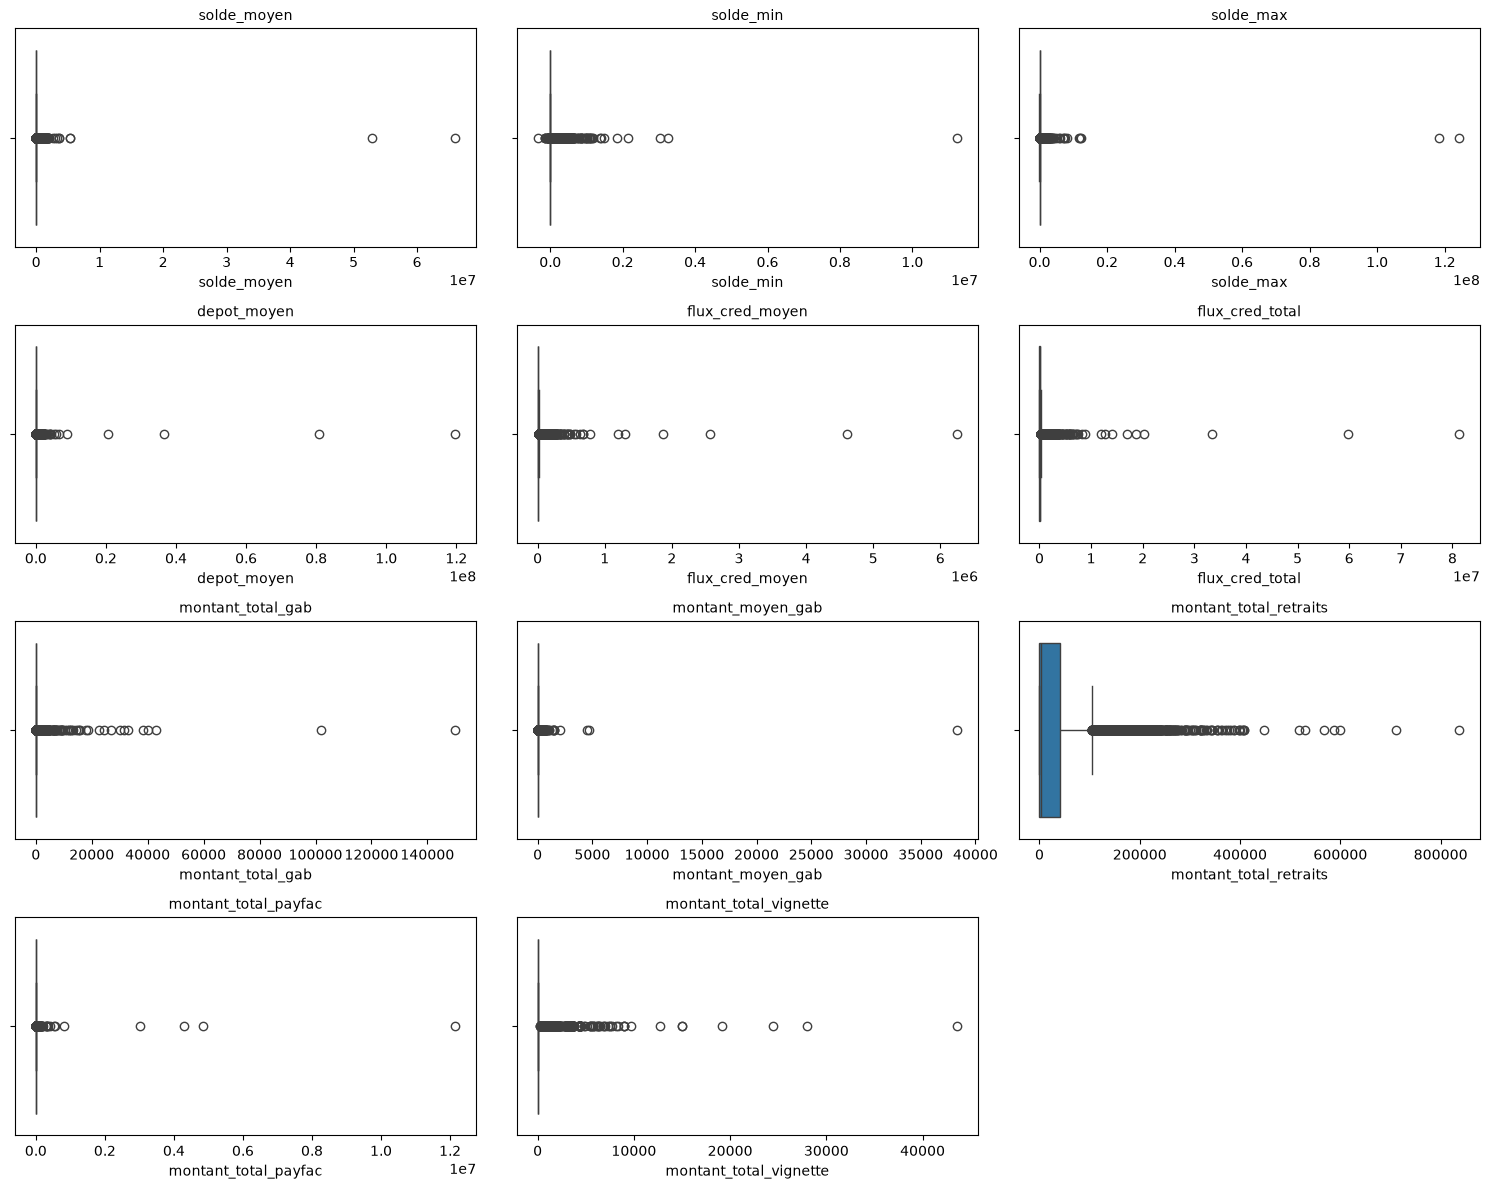

  Lignes avant/après (valeurs impossibles, train) : 95326 -> 95326

Détection des colonnes zero-inflated (train) :
  montant_total_gab            -> zero-inflated (93% de zéros)
  montant_moyen_gab            -> zero-inflated (93% de zéros)
  montant_total_payfac         -> zero-inflated (80% de zéros)
  montant_total_vignette       -> zero-inflated (95% de zéros)

Bornes apprises sur le train (11 colonnes) :
  solde_moyen                  -> [-17120.7, 28334.3]
  solde_min                    -> [-1033.2, 847.1]
  solde_max                    -> [-61237.2, 102300.6]
  depot_moyen                  -> [-27107.9, 45272.5]
  flux_cred_moyen              -> [-10088.1, 16813.5]
  flux_cred_total              -> [-139151.8, 231919.7]
  montant_total_gab            -> [-1008.2, 1733.8] [zero-inflated]
  montant_moyen_gab            -> [-29.3, 49.6] [zero-inflated]
  montant_total_retraits       -> [-60750.0, 101250.0]
  montant_total_payfac         -> [-12443.8, 22495.0] [zero-inflated]
  mont

montant_total_vignette       min=         0.0 max=        2950.0 mean=73.0 médiane=0.0 p1=0.0 p99=2950.0 bornes_IQR=[0.0,0.0] négatifs=0 hors_bornes=4870


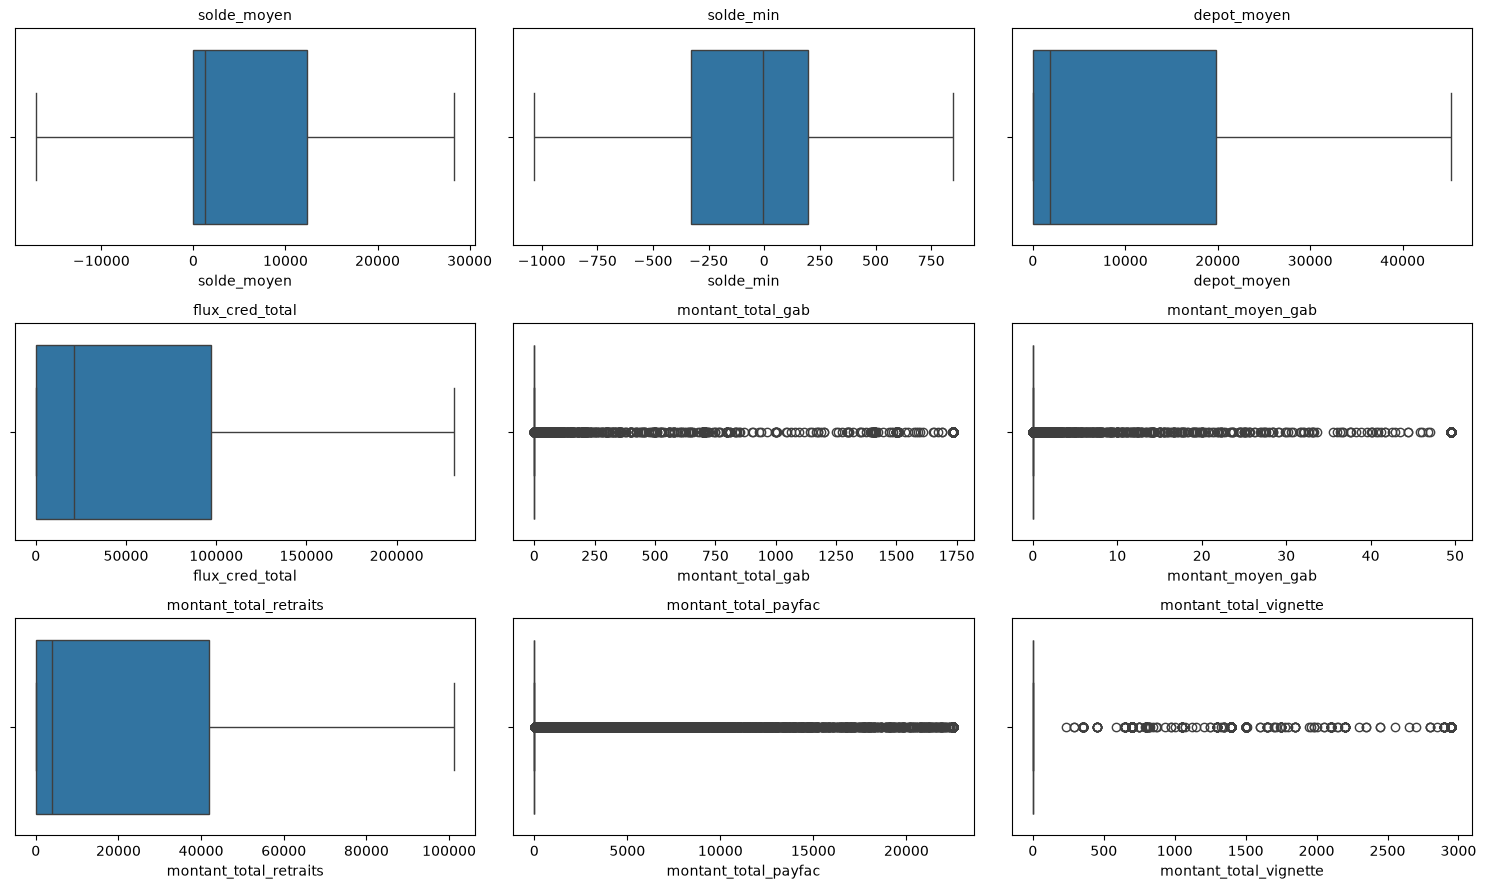


Équilibre des classes de la cible (label_eligibilite) :
+-----------------+-----+
|label_eligibilite|count|
+-----------------+-----+
|0                |91321|
|1                |4005 |
+-----------------+-----+


Écriture : new_test/part-00000_eligibilite_final.parquet


OK : dataset_eligibilite -> 95326 lignes, 40 colonnes.


In [21]:
df_train_final = traiter_dataset(PATH_TRAIN_IN, PATH_TRAIN_OUT, is_train=True, label=f"dataset_{DATASET_CIBLE}")


26/07/15 10:37:50 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS



Paires corrélées (|r| >= 0.85) :
  depot_moyen  <->  depot_moyen_etait_extreme   (r = 0.861)
  flux_cred_moyen_etait_extreme  <->  flux_cred_total_etait_extreme   (r = 0.882)


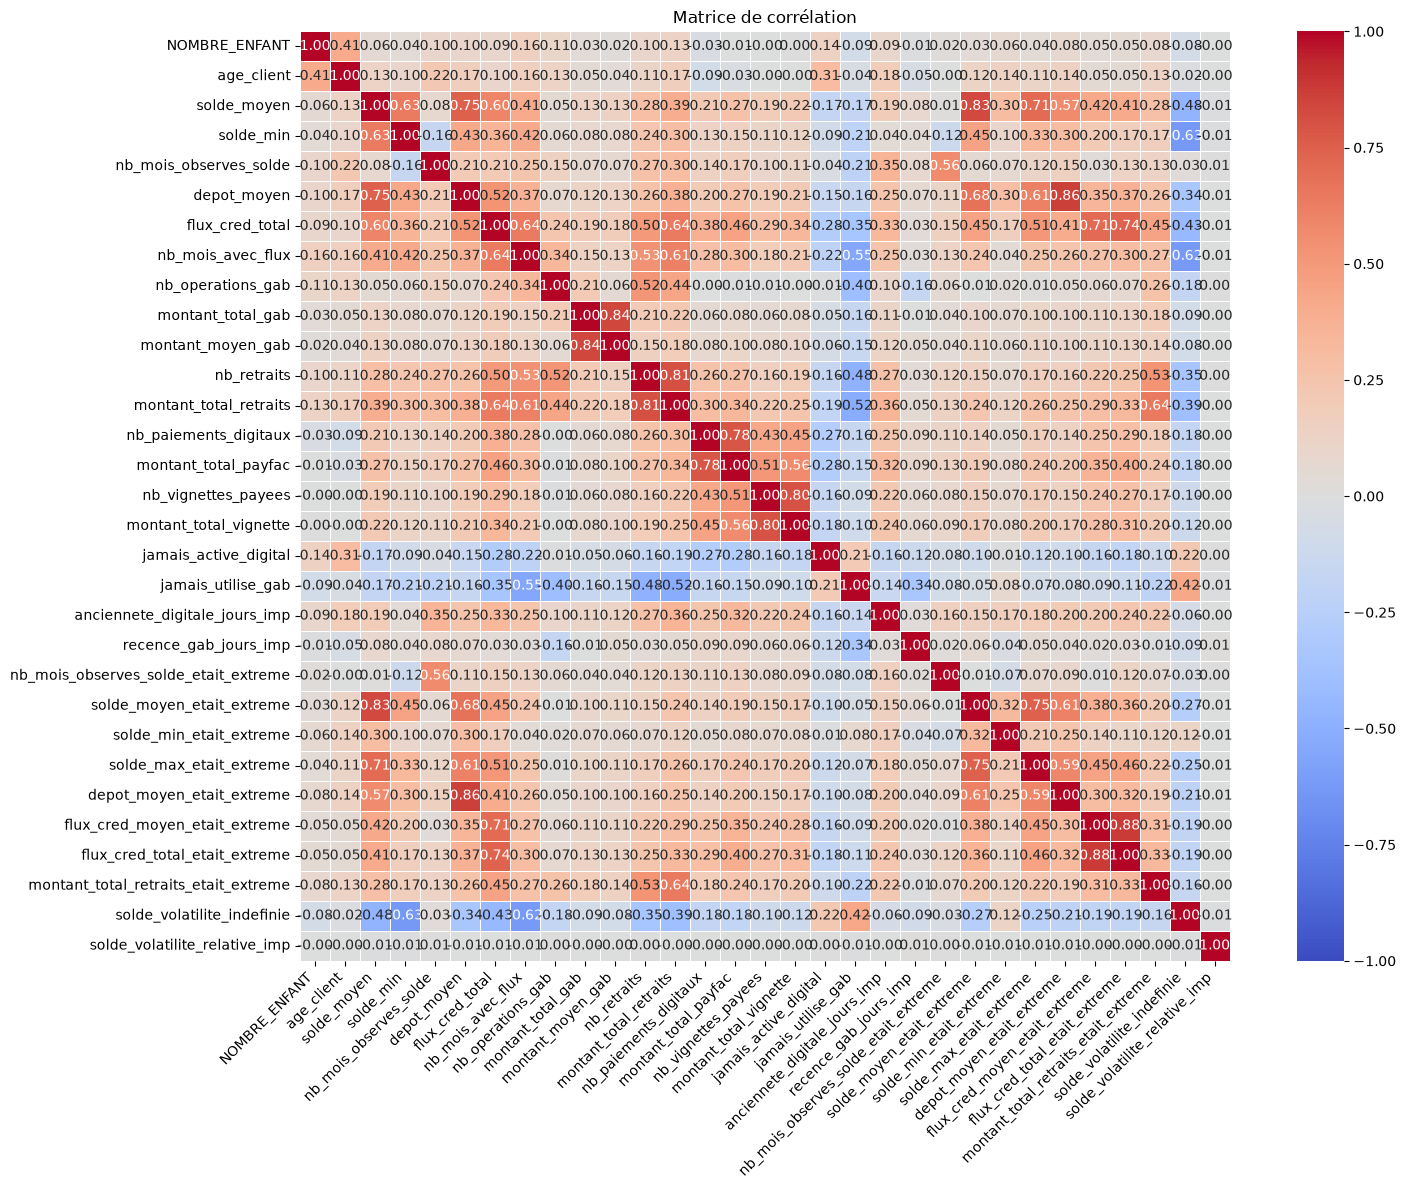

In [22]:
diagnostic_correlations(df_train_final)


In [23]:
df_train_final.groupBy("solde_moyen_etait_extreme").count().show()


+-------------------------+-----+
|solde_moyen_etait_extreme|count|
+-------------------------+-----+
|                        1|15270|
|                        0|80056|
+-------------------------+-----+



In [24]:
import pandas as pd

# CORRECTIF : chemin absolu codé en dur, propre à une seule machine/utilisateur et
# indépendant du LOCAL_MODE/PATH_TRAIN_OUT défini en section 0. Si ce chemin ne
# correspond pas exactement à l'endroit où traiter_dataset() a écrit (cwd différent,
# autre machine), pandas relit silencieusement un ancien parquet -> colonnes qui
# semblent "vides" ou incohérentes alors que le run actuel est bon.
# Rappel (recadrage) : ce fichier correspond au dataset courant, DATASET_CIBLE = "{DATASET_CIBLE}"
# -- pensez à noter/renommer si vous gardez les deux exports côte à côte.
print(f"Dataset courant : {DATASET_CIBLE}")
path = PATH_TRAIN_OUT
df = pd.read_parquet(path)

display(df.head())

# Réutilisé tel quel par la Partie 2 (exploration visuelle pandas) plus bas.
df.to_csv(PATH_TRAIN_OUT_CSV, index=False)
print(f"Export CSV : {PATH_TRAIN_OUT_CSV} ({df.shape[0]} lignes, {df.shape[1]} colonnes)")


Dataset courant : eligibilite


,CODE_VILLE,BPR,GENDER,MARITAL_STATUS,NOMBRE_ENFANT,CUSTOMER_RATING,TAILLE_ENTREPRI,age_client,pack_actuel,pack_etat,...,nb_mois_observes_solde_etait_extreme,solde_moyen_etait_extreme,solde_min_etait_extreme,solde_max_etait_extreme,depot_moyen_etait_extreme,flux_cred_moyen_etait_extreme,flux_cred_total_etait_extreme,montant_total_retraits_etait_extreme,solde_volatilite_indefinie,solde_volatilite_relative_imp
0,450,45,F,1,0,SVC,PARTICULIER,49,PFA01,W,...,0,0,0,0,0,0,0,0,1,3.580593
1,780,78,F,1,0,SVC,PARTICULIER,33,PFA01,W,...,0,0,1,0,0,0,0,0,1,3.580593
2,590,45,M,1,0,SVC,PARTICULIER,30,SANS_PACK,SANS_ETAT,...,0,0,0,0,0,0,0,0,1,3.580593
3,780,78,F,1,0,SVC,PARTICULIER,47,PFA01,W,...,0,0,1,0,0,0,0,0,1,3.580593
4,720,64,F,9,0,JNE,PARTICULIER,24,PJUN5,W,...,0,0,0,0,0,0,0,0,0,14.359640


Export CSV : final_eligibilite.csv (95326 lignes, 40 colonnes)


**Scoring de production (hors-scope de ce notebook, recadrage)** :

Contrairement aux versions précédentes, il n'y a plus de bloc "scoring" ici : le nettoyage de
`dataset_eligibilite`/`dataset_produit` (ce notebook) alimente l'entraînement, pas le scoring.
Le scoring de **vrais nouveaux clients** (sans historique de label du tout) réutilise les
artefacts sauvegardés ci-dessus (`IMPUTER_MODEL_PATH`, `OUTLIER_BOUNDS_PATH`, etc., un jeu par
`DATASET_CIBLE`) mais s'exécute dans le pipeline de scoring batch en cascade du Sprint 3
(`GUIDE_MAITRE.md`, section 8) : d'abord le modèle d'éligibilité sur tous les nouveaux clients,
puis le modèle produit uniquement sur ceux prédits éligibles.

In [25]:
# Volontairement vide : voir la note ci-dessus. Le nettoyage de nouveaux clients à noter en
# production est fait par scoring_batch.py (Sprint 3), en rechargeant les artefacts sauvegardés
# par ce notebook (is_train=False dans traiter_dataset), pas ici.


---
## PARTIE 2 — Exploration visuelle du dataset nettoyé (pandas)

**Dépend de la Partie 1** : lit le CSV désigné par `PATH_TRAIN_OUT_CSV`, écrit par la toute
dernière cellule de la section 10 ci-dessus, **pour le `DATASET_CIBLE` actuellement configuré**
(section 0). Si ce fichier date d'une exécution précédente, ou d'un `DATASET_CIBLE` différent de
celui que vous voulez explorer, relancez la Partie 1 avant de relancer cette partie.

**Objectif** : comprendre chaque colonne, sa distribution, et les relations entre colonnes (y
compris avec la variable cible `COL_CIBLE` -- `label_eligibilite` ou `label_nom`/`label_code`
selon le `DATASET_CIBLE` en cours, définie section 0).

**Plan** :
1. Chargement & aperçu général
2. Qualité des données (valeurs manquantes, doublons, cardinalité)
3. Variable cible
4. Distribution des variables numériques
5. Distribution des variables catégorielles
6. Colonnes indicatrices / flags binaires
7. Corrélations entre variables numériques
8. Relations variables numériques ↔ cible
9. Relations variables catégorielles ↔ cible
10. Synthèse

## 1. Setup & chargement des données

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 100)

# CORRECTIF : pointe maintenant sur PATH_TRAIN_OUT_CSV défini/écrit en Partie 1 (section 0/10)
# au lieu d'un "final.csv" en dur -- l'ancienne valeur en dur lisait, lors d'une vérification,
# un fichier qui contenait encore RADICAL/BANQUE/DATE_OF_BIRTH/digital_date_activation, preuve
# qu'il s'agissait d'une sortie pré-nettoyage et pas de la sortie réelle du pipeline.
DATA_PATH = PATH_TRAIN_OUT_CSV if "PATH_TRAIN_OUT_CSV" in dir() else "final.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(95326, 40)


/tmp/ipykernel_295561/1147223100.py:15: DtypeWarning: Columns (0: MARITAL_STATUS) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,CODE_VILLE,BPR,GENDER,MARITAL_STATUS,NOMBRE_ENFANT,CUSTOMER_RATING,TAILLE_ENTREPRI,age_client,pack_actuel,pack_etat,solde_moyen,solde_min,nb_mois_observes_solde,depot_moyen,flux_cred_total,nb_mois_avec_flux,nb_operations_gab,montant_total_gab,montant_moyen_gab,nb_retraits,montant_total_retraits,nb_paiements_digitaux,montant_total_payfac,nb_vignettes_payees,montant_total_vignette,label_eligibilite,jamais_active_digital,jamais_utilise_gab,anciennete_digitale_jours_imp,recence_gab_jours_imp,nb_mois_observes_solde_etait_extreme,solde_moyen_etait_extreme,solde_min_etait_extreme,solde_max_etait_extreme,depot_moyen_etait_extreme,flux_cred_moyen_etait_extreme,flux_cred_total_etait_extreme,montant_total_retraits_etait_extreme,solde_volatilite_indefinie,solde_volatilite_relative_imp
0,450,45,F,1,0,SVC,PARTICULIER,49,PFA01,W,-169.820833,-591.750,24,149.9350,0.0,0,3,0.0,0.0,1,200.0,0,0.0,0,0.0,0,0,0,2260,600,0,0,0,0,0,0,0,0,1,3.580593
1,780,78,F,1,0,SVC,PARTICULIER,33,PFA01,W,-4075.492500,-1033.215,24,0.0000,0.0,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0,0,1,2975,496,0,0,1,0,0,0,0,0,1,3.580593
2,590,45,M,1,0,SVC,PARTICULIER,30,SANS_PACK,SANS_ETAT,-845.681667,-974.840,24,0.0000,0.0,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0,1,1,2358,496,0,0,0,0,0,0,0,0,1,3.580593
3,780,78,F,1,0,SVC,PARTICULIER,47,PFA01,W,-3665.306250,-1033.215,24,0.0000,0.0,0,0,0.0,0.0,0,0.0,0,0.0,0,0.0,0,1,1,2358,496,0,0,1,0,0,0,0,0,1,3.580593
4,720,64,F,9,0,JNE,PARTICULIER,24,PJUN5,W,458.423750,-183.700,16,1130.3475,0.0,0,10,30.0,3.0,4,9000.0,0,0.0,0,0.0,0,0,0,919,612,0,0,0,0,0,0,0,0,0,14.359640


In [27]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CODE_VILLE,95326,862,780,14592,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BPR,95326.0,NaN,NaN,NaN,51.197092,25.981212,1.0,27.0,50.0,78.0,90.0
GENDER,95326,2,M,63551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MARITAL_STATUS,95326.0,11.0,3.0,25148.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMBRE_ENFANT,95326.0,NaN,NaN,NaN,0.629923,1.204748,0.0,0.0,0.0,1.0,12.0
CUSTOMER_RATING,95326,18,SVC,44388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TAILLE_ENTREPRI,95326,2,PARTICULIER,95304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_client,95326.0,NaN,NaN,NaN,44.206334,12.860503,18.0,34.0,44.0,55.0,69.0
pack_actuel,95326,81,SANS_PACK,26645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pack_etat,95326,3,W,62161,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Qualité des données

Valeurs manquantes, doublons, cardinalité de chaque colonne.

In [28]:
n_dupes = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {n_dupes}")

n_missing = df.isnull().sum()
n_missing = n_missing[n_missing > 0].sort_values(ascending=False)
if len(n_missing):
    print("\nColonnes avec valeurs manquantes (ne devrait plus arriver après les correctifs de la Partie 1) :")
    print(n_missing)
else:
    print("Aucune valeur manquante -- cohérent avec les règles de nulls de la section 2 (Partie 1).")


Nombre de lignes dupliquées : 195
Aucune valeur manquante -- cohérent avec les règles de nulls de la section 2 (Partie 1).


In [29]:
cardinality = df.nunique().sort_values(ascending=False)
cardinality.to_frame("n_valeurs_uniques")


,n_valeurs_uniques
solde_moyen,74094
solde_volatilite_relative_imp,58492
depot_moyen,56789
flux_cred_total,46153
solde_min,32629
montant_total_payfac,12762
anciennete_digitale_jours_imp,5364
montant_moyen_gab,3352
montant_total_gab,1072
montant_total_retraits,1014


## 3. Variable cible

`COL_CIBLE` (définie section 0) pointe vers `label_eligibilite` (binaire, `dataset_eligibilite`)
ou `label_nom`/`label_code` (3 classes, `dataset_produit`) selon le `DATASET_CIBLE` en cours.

In [30]:
target_counts = df[COL_CIBLE].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=target_counts.values, y=target_counts.index, ax=axes[0], color="#2980b9")
axes[0].set_xlabel("Nombre de clients")
axes[0].set_title(f"Distribution de {COL_CIBLE}")
for i, v in enumerate(target_counts.values):
    axes[0].text(v, i, f" {v} ({target_pct.iloc[i]}%)", va="center")

axes[1].pie(target_counts.values, labels=target_counts.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("deep"))
axes[1].set_title("Répartition (%)")
plt.tight_layout()
plt.show()

print("Déséquilibre des classes — à garder en tête pour la modélisation (pondération de classes,")
print("sur/sous-échantillonnage, ou métriques adaptées comme F1/AUC-PR plutôt que l'accuracy brute).")


/tmp/ipykernel_295561/3946859376.py:14: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


ValueError: Image size of 19302258x439 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 1200x450 with 2 Axes>

Déséquilibre des classes — à garder en tête pour la modélisation (pondération de classes,
sur/sous-échantillonnage, ou métriques adaptées comme F1/AUC-PR plutôt que l'accuracy brute).


## 4. Distribution des variables numériques

On sépare les variables numériques "continues/comptages" des colonnes indicatrices binaires
(`*_etait_extreme`, `jamais_*`), traitées séparément en section 6.

In [31]:
all_num_cols = df.select_dtypes(include="number").columns.tolist()

flag_cols = [c for c in all_num_cols if c.endswith("_etait_extreme") or c.startswith("jamais_")]
# CORRECTIF (recadrage) : label_code (produit) et label_eligibilite (éligibilité) sont tous les
# deux des colonnes numériques qui encodent une CIBLE, pas une feature continue -- exclues des
# deux côtés, peu importe le DATASET_CIBLE en cours (l'une des deux est de toute façon absente).
target_like = [c for c in ["label_code", "label_eligibilite"] if c in df.columns]
real_num_cols = [c for c in all_num_cols if c not in flag_cols and c not in target_like]

print(f"Variables numériques 'continues' : {len(real_num_cols)}")
print(real_num_cols)
print()
print(f"Colonnes indicatrices binaires : {len(flag_cols)}")
print(flag_cols)


Variables numériques 'continues' : 22
['BPR', 'NOMBRE_ENFANT', 'age_client', 'solde_moyen', 'solde_min', 'nb_mois_observes_solde', 'depot_moyen', 'flux_cred_total', 'nb_mois_avec_flux', 'nb_operations_gab', 'montant_total_gab', 'montant_moyen_gab', 'nb_retraits', 'montant_total_retraits', 'nb_paiements_digitaux', 'montant_total_payfac', 'nb_vignettes_payees', 'montant_total_vignette', 'anciennete_digitale_jours_imp', 'recence_gab_jours_imp', 'solde_volatilite_indefinie', 'solde_volatilite_relative_imp']

Colonnes indicatrices binaires : 10
['jamais_active_digital', 'jamais_utilise_gab', 'nb_mois_observes_solde_etait_extreme', 'solde_moyen_etait_extreme', 'solde_min_etait_extreme', 'solde_max_etait_extreme', 'depot_moyen_etait_extreme', 'flux_cred_moyen_etait_extreme', 'flux_cred_total_etait_extreme', 'montant_total_retraits_etait_extreme']


In [32]:
df[real_num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
BPR,95326.0,51.197092,25.981212,1.000000,27.000000,50.000000,78.000000,90.000000
NOMBRE_ENFANT,95326.0,0.629923,1.204748,0.000000,0.000000,0.000000,1.000000,12.000000
age_client,95326.0,44.206334,12.860503,18.000000,34.000000,44.000000,55.000000,69.000000
solde_moyen,95326.0,7269.612606,10924.949844,-17120.651667,-64.494567,1339.975833,12137.861875,28334.288333
solde_min,95326.0,-49.623767,606.060041,-1033.215000,-321.125000,-5.500000,182.500000,847.065000
nb_mois_observes_solde,95326.0,23.115855,6.707032,1.000000,24.000000,24.000000,24.000000,36.000000
depot_moyen,95326.0,12097.877963,17232.879099,0.000000,45.242500,1834.030067,19664.200385,45272.472929
flux_cred_total,95326.0,60246.290415,77565.158730,0.000000,0.000000,21401.000000,95195.500000,231919.675000
nb_mois_avec_flux,95326.0,6.865755,5.798010,0.000000,0.000000,8.000000,13.000000,39.000000
nb_operations_gab,95326.0,19.485156,49.265567,0.000000,0.000000,0.000000,14.000000,1623.000000


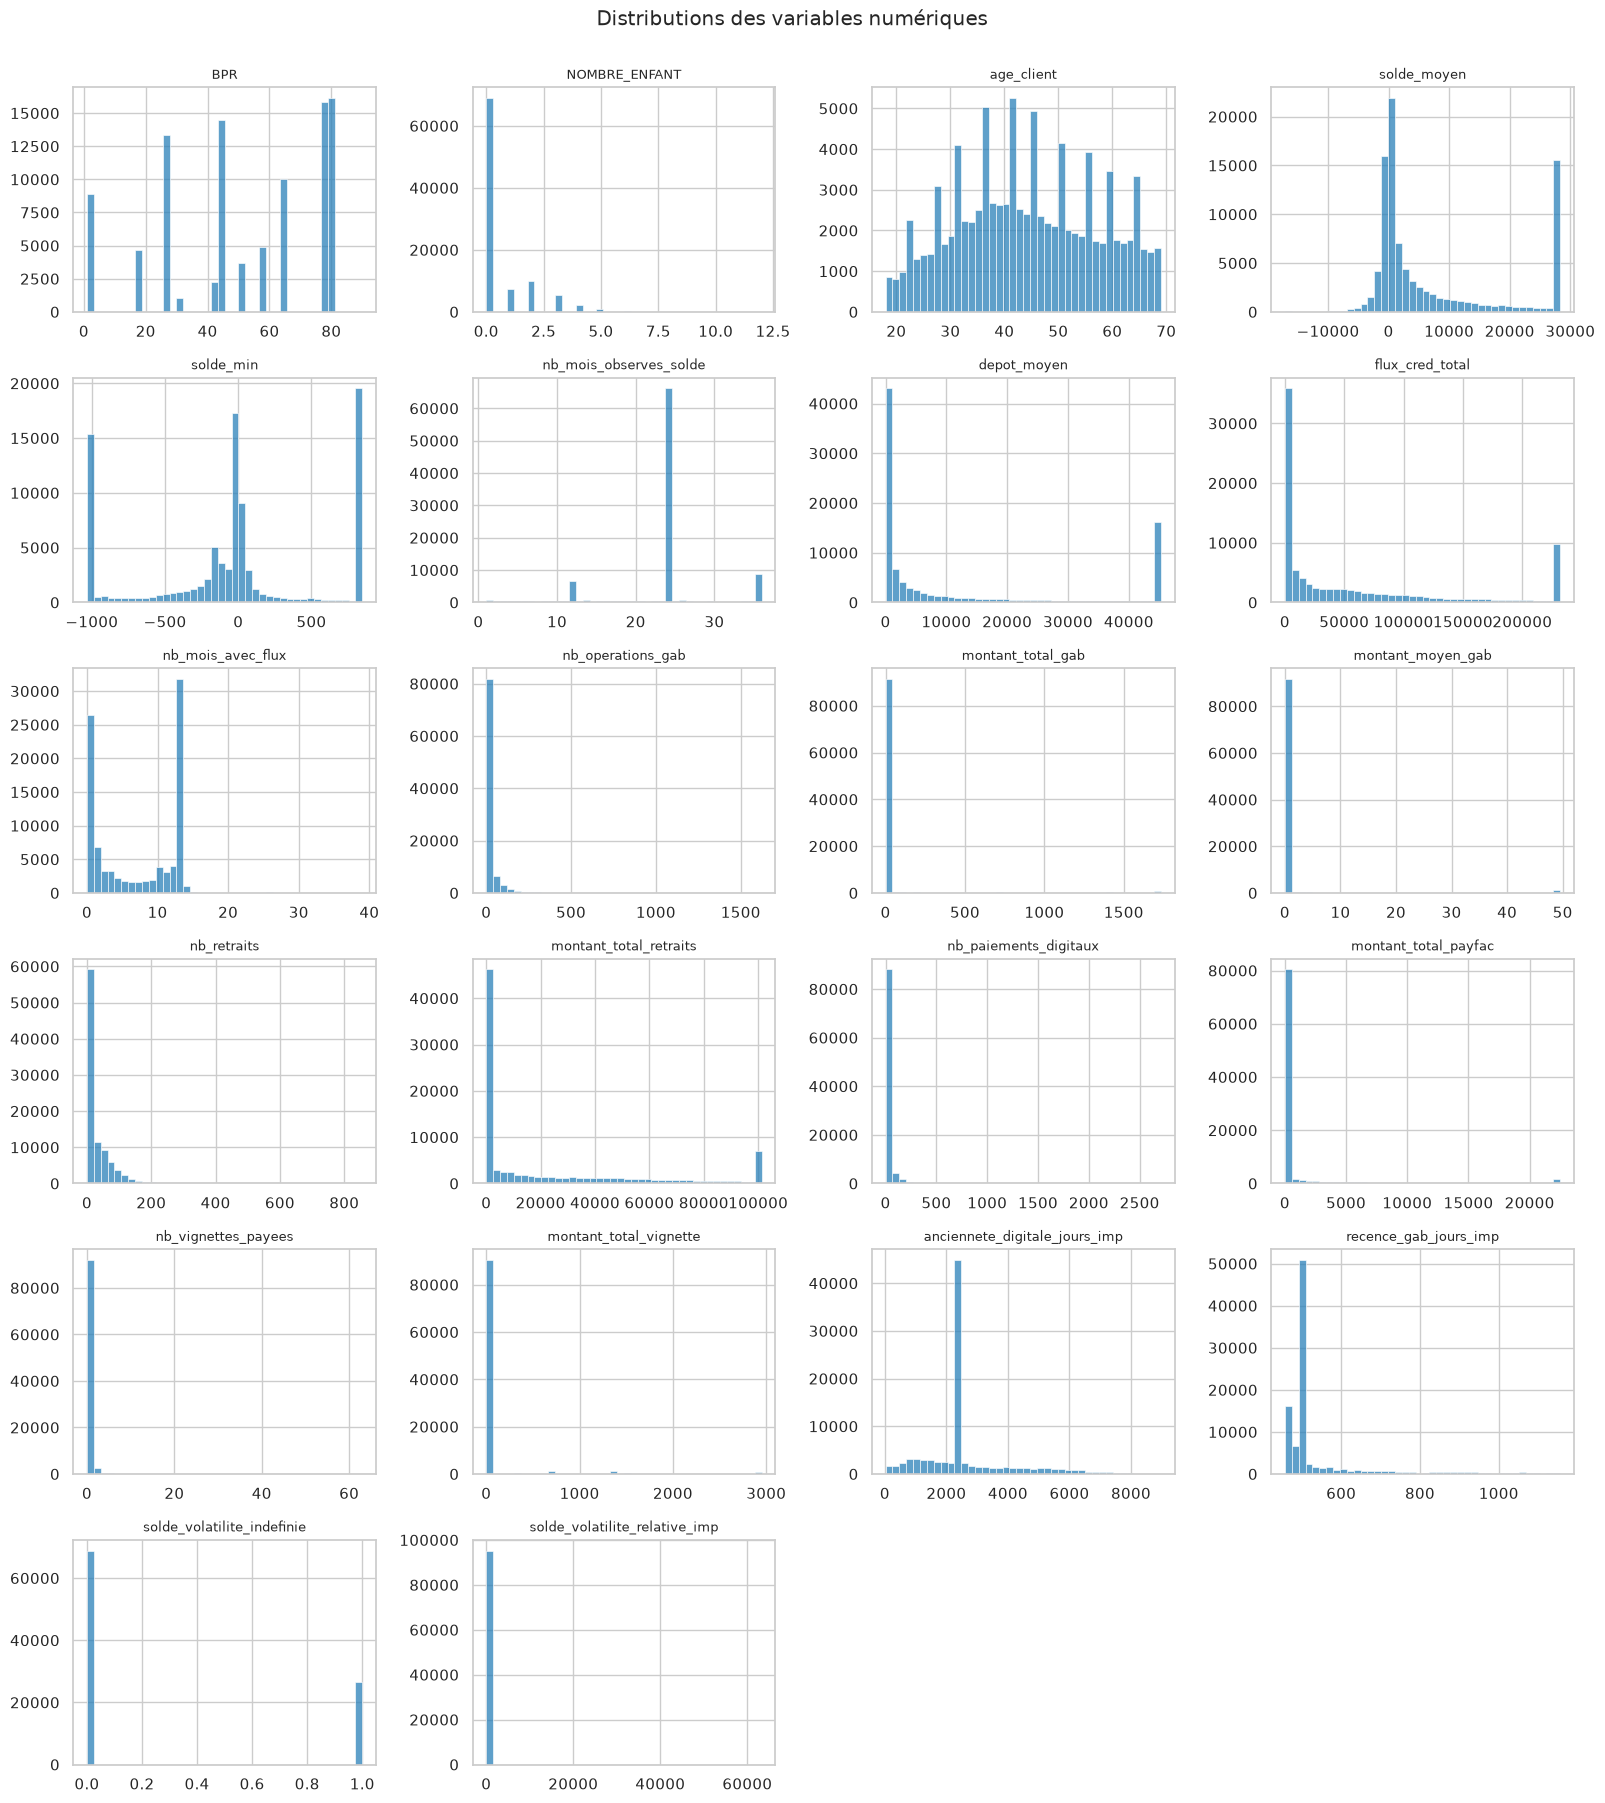

In [33]:
# Histogrammes de toutes les variables numériques "continues"
n = len(real_num_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes = axes.flatten()

for i, col in enumerate(real_num_cols):
    ax = axes[i]
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color="#2980b9", kde=False)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distributions des variables numériques", y=1.001)
plt.tight_layout()
plt.show()


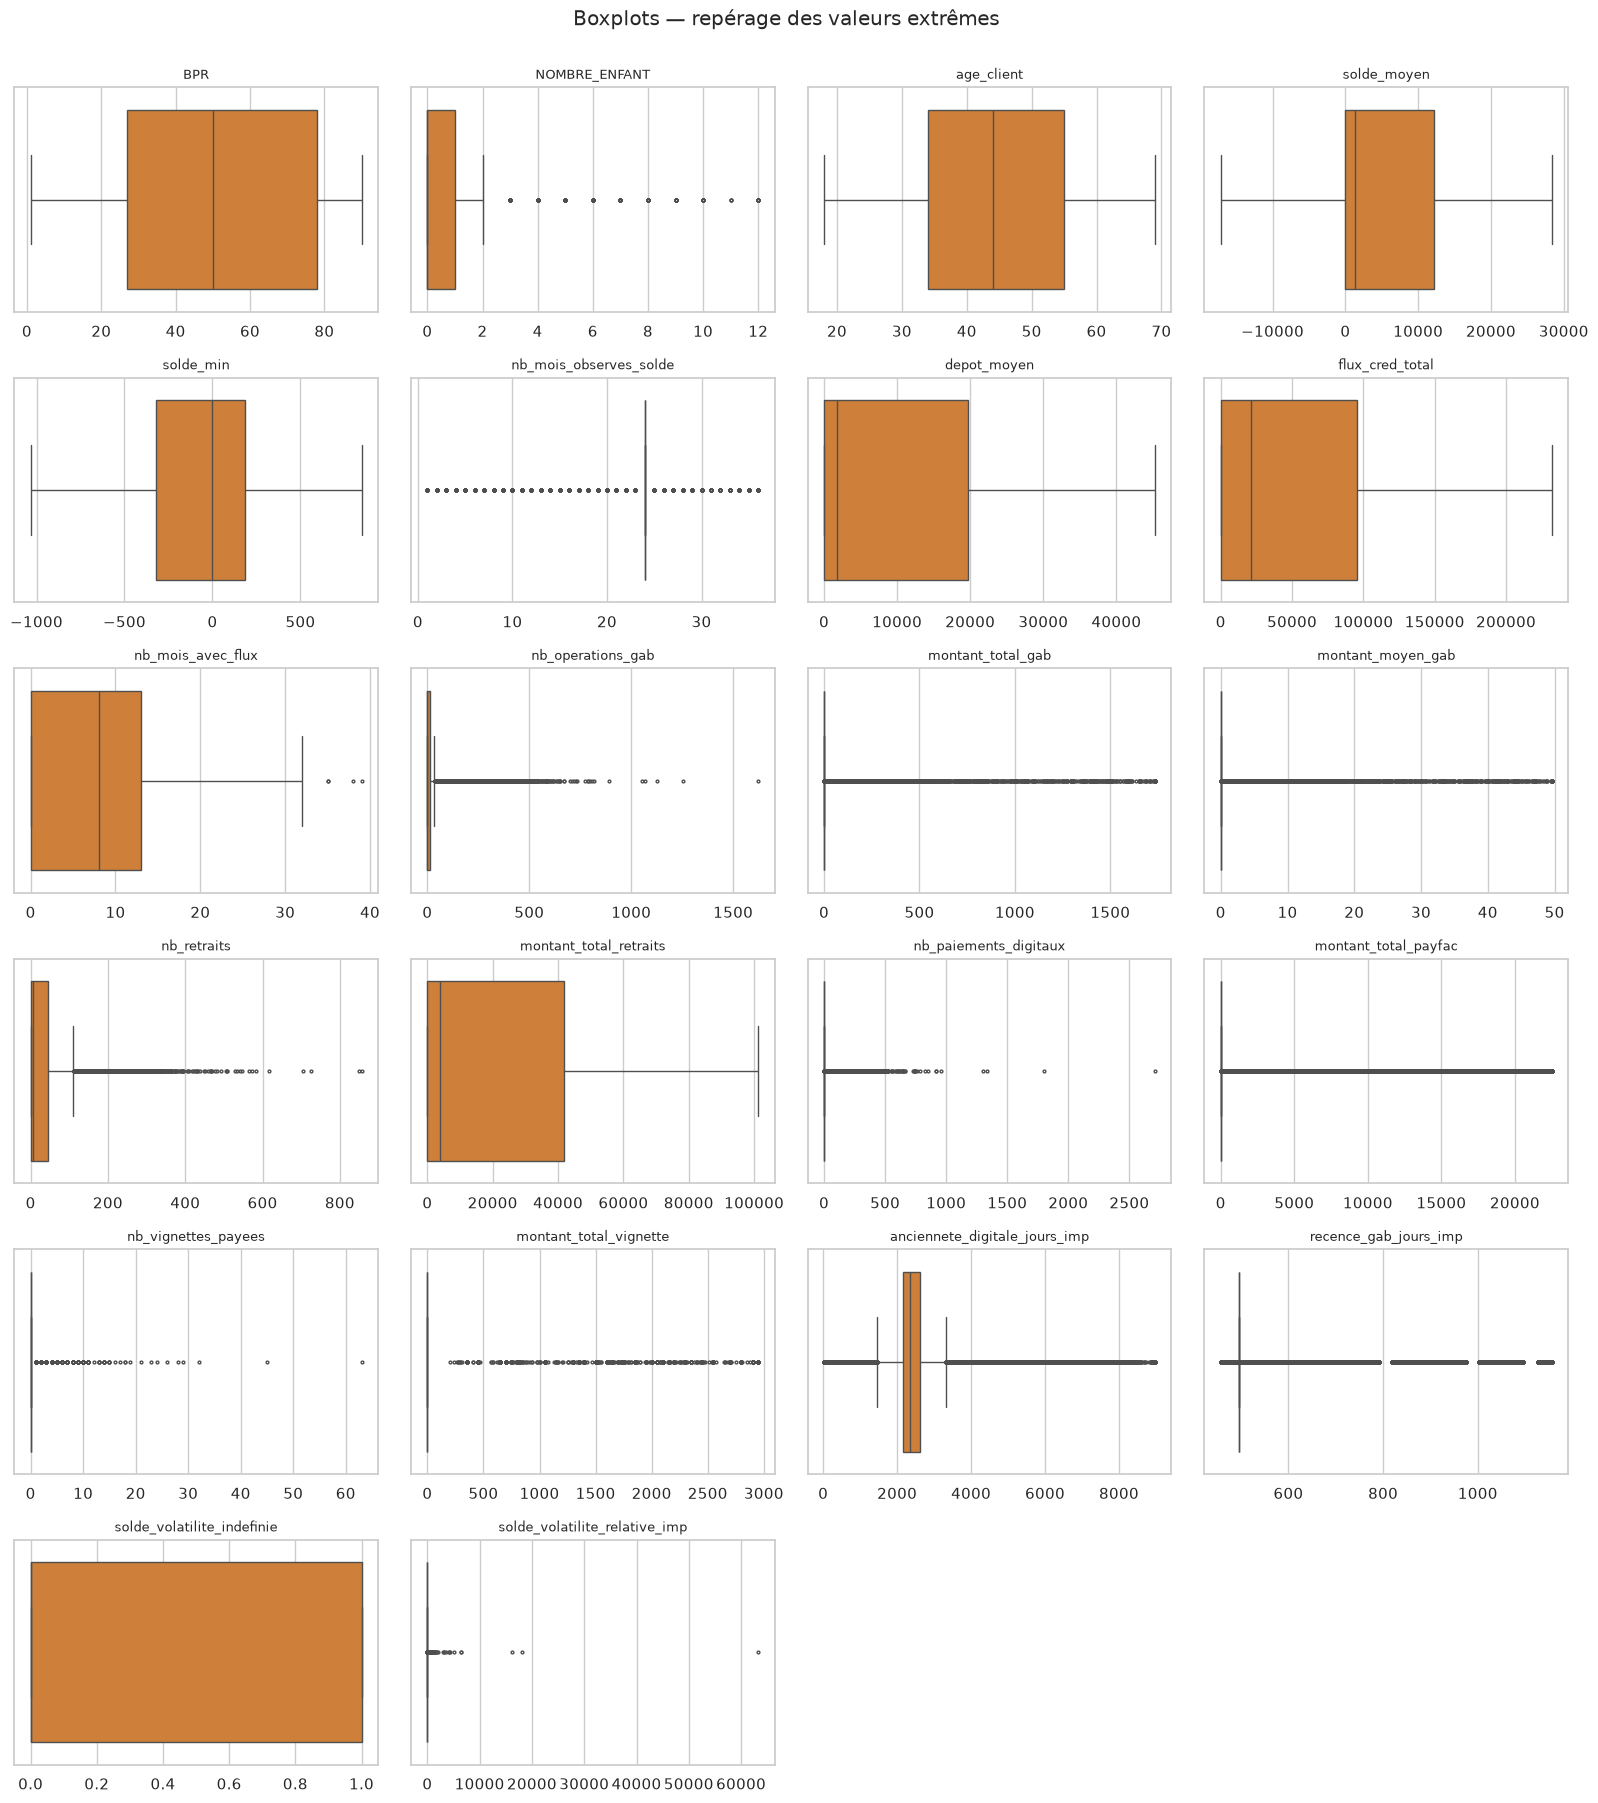

In [34]:
# Boxplots pour repérer visuellement les outliers
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
axes = axes.flatten()

for i, col in enumerate(real_num_cols):
    ax = axes[i]
    sns.boxplot(x=df[col].dropna(), ax=ax, color="#e67e22", fliersize=2)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Boxplots — repérage des valeurs extrêmes", y=1.001)
plt.tight_layout()
plt.show()


In [35]:
# Skewness / asymétrie de chaque variable numérique continue
skew_df = df[real_num_cols].skew().sort_values(ascending=False).to_frame("skewness")
skew_df["interpretation"] = pd.cut(
    skew_df["skewness"].abs(),
    bins=[-0.01, 0.5, 1, np.inf],
    labels=["≈ symétrique", "modérément asymétrique", "fortement asymétrique"]
)
skew_df


,skewness,interpretation
solde_volatilite_relative_imp,241.887088,fortement asymétrique
nb_vignettes_payees,17.788736,fortement asymétrique
nb_paiements_digitaux,8.015634,fortement asymétrique
montant_moyen_gab,7.522459,fortement asymétrique
montant_total_gab,7.342903,fortement asymétrique
montant_total_vignette,5.879536,fortement asymétrique
nb_operations_gab,5.478453,fortement asymétrique
montant_total_payfac,3.873732,fortement asymétrique
recence_gab_jours_imp,2.813725,fortement asymétrique
nb_retraits,2.728651,fortement asymétrique


## 5. Distribution des variables catégorielles

Pour les colonnes à forte cardinalité (`CODE_VILLE`, `pack_actuel`), seules les modalités les plus
fréquentes sont affichées.

In [36]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != COL_CIBLE]  # déjà traité en section 3 (COL_CIBLE peut être object ou numérique)
print(cat_cols)


['CODE_VILLE', 'GENDER', 'MARITAL_STATUS', 'CUSTOMER_RATING', 'TAILLE_ENTREPRI', 'pack_actuel', 'pack_etat']


/tmp/ipykernel_295561/2541327143.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


In [37]:
for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"{col} : {n_unique} modalités")


CODE_VILLE : 862 modalités
GENDER : 2 modalités
MARITAL_STATUS : 11 modalités
CUSTOMER_RATING : 18 modalités
TAILLE_ENTREPRI : 2 modalités
pack_actuel : 81 modalités
pack_etat : 3 modalités


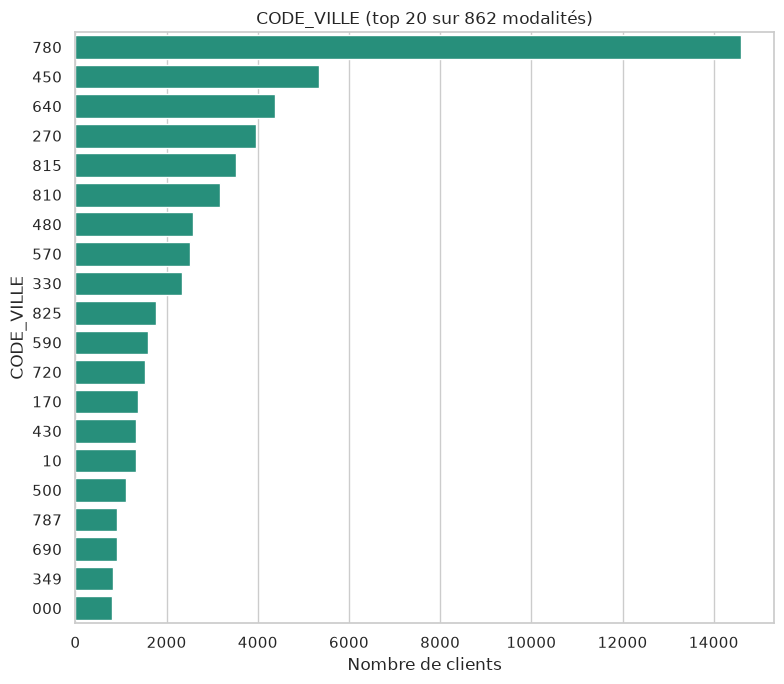

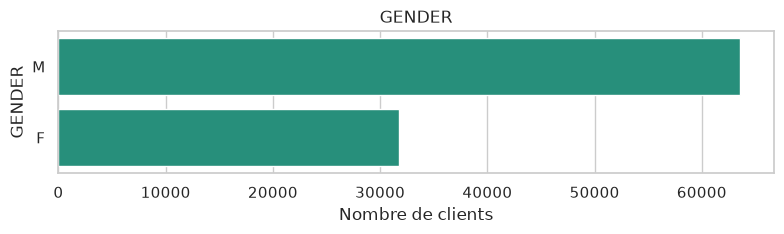

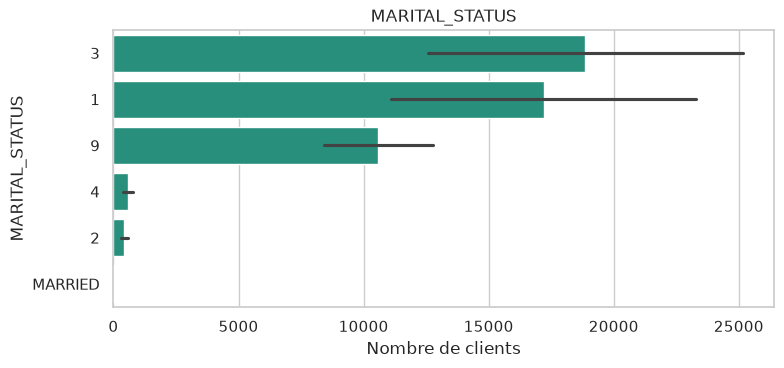

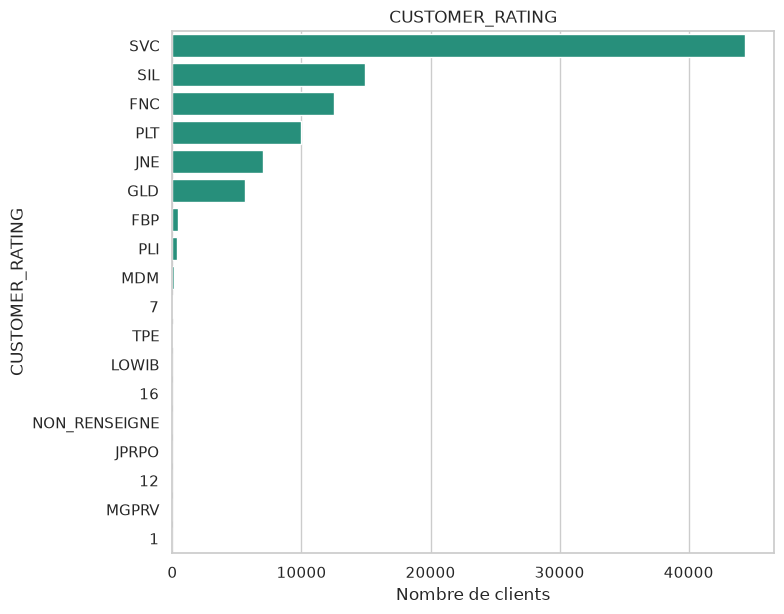

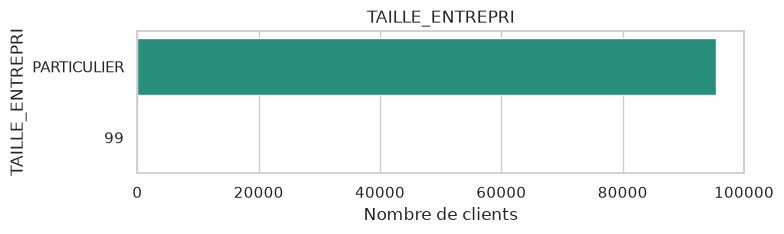

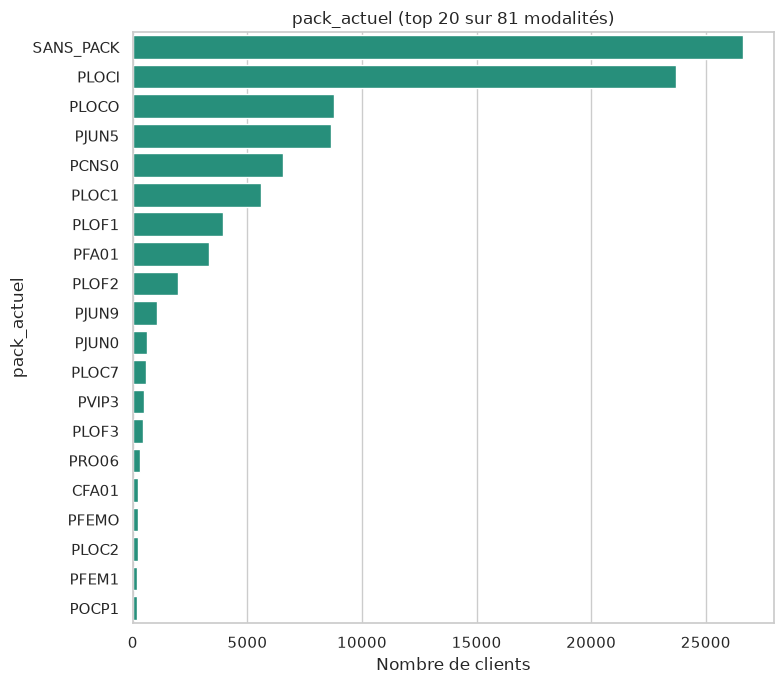

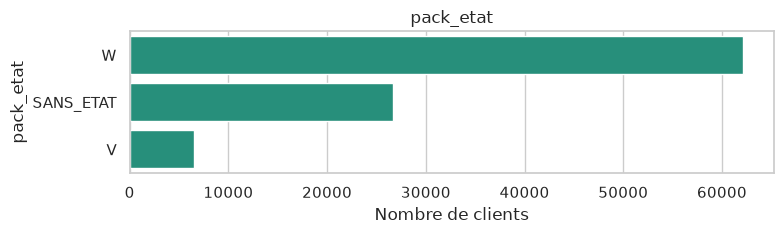

In [38]:
# CORRECTIF : la version précédente réutilisait `n_unique` laissé en mémoire par la
# cellule ci-dessus (valeur figée = dernière colonne de cette boucle-là), pas la
# cardinalité réelle de la colonne courante -- le titre "top 20 sur X modalités"
# était donc faux pour toutes les colonnes sauf une. Recalculé ici, par colonne.
for col in cat_cols:
    n_unique_col = df[col].nunique()
    counts = df[col].value_counts()
    top = counts.head(20)
    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.35*len(top))))
    sns.barplot(x=top.values, y=top.index.astype(str), ax=ax, color="#16a085")
    title = col if n_unique_col <= 20 else f"{col} (top 20 sur {n_unique_col} modalités)"
    ax.set_title(title)
    ax.set_xlabel("Nombre de clients")
    plt.tight_layout()
    plt.show()


## 6. Colonnes indicatrices / flags binaires

Proportion de clients à 1 pour chaque flag (`*_etait_extreme`, `jamais_active_digital`,
`jamais_utilise_gab`, ...).

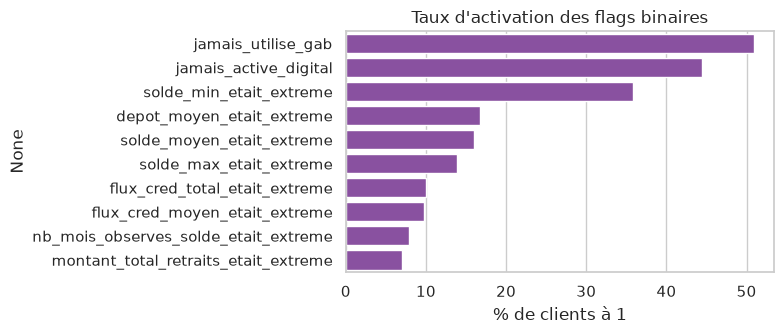

,pct_a_1
jamais_utilise_gab,50.876991
jamais_active_digital,44.420200
solde_min_etait_extreme,35.808699
depot_moyen_etait_extreme,16.680654
solde_moyen_etait_extreme,16.018715
solde_max_etait_extreme,13.858758
flux_cred_total_etait_extreme,9.967900
flux_cred_moyen_etait_extreme,9.746554
nb_mois_observes_solde_etait_extreme,7.935925
montant_total_retraits_etait_extreme,7.028513


In [39]:
flag_rates = (df[flag_cols].mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, max(3, 0.35*len(flag_cols))))
sns.barplot(x=flag_rates.values, y=flag_rates.index, ax=ax, color="#8e44ad")
ax.set_xlabel("% de clients à 1")
ax.set_title("Taux d'activation des flags binaires")
plt.tight_layout()
plt.show()

flag_rates.to_frame("pct_a_1")


## 7. Corrélations entre variables numériques

Matrice de corrélation (Pearson) sur les variables numériques continues. `CODE_VILLE` et `BPR`
restent dans `real_num_cols` (ce sont des `int` dans le CSV) mais sont des codes catégoriels, pas
des grandeurs continues — leur corrélation avec le reste n'a pas de sens et peut être ignorée
dans la lecture de la matrice ci-dessous (même logique que l'exclusion faite côté Spark en
Partie 1, section 6).

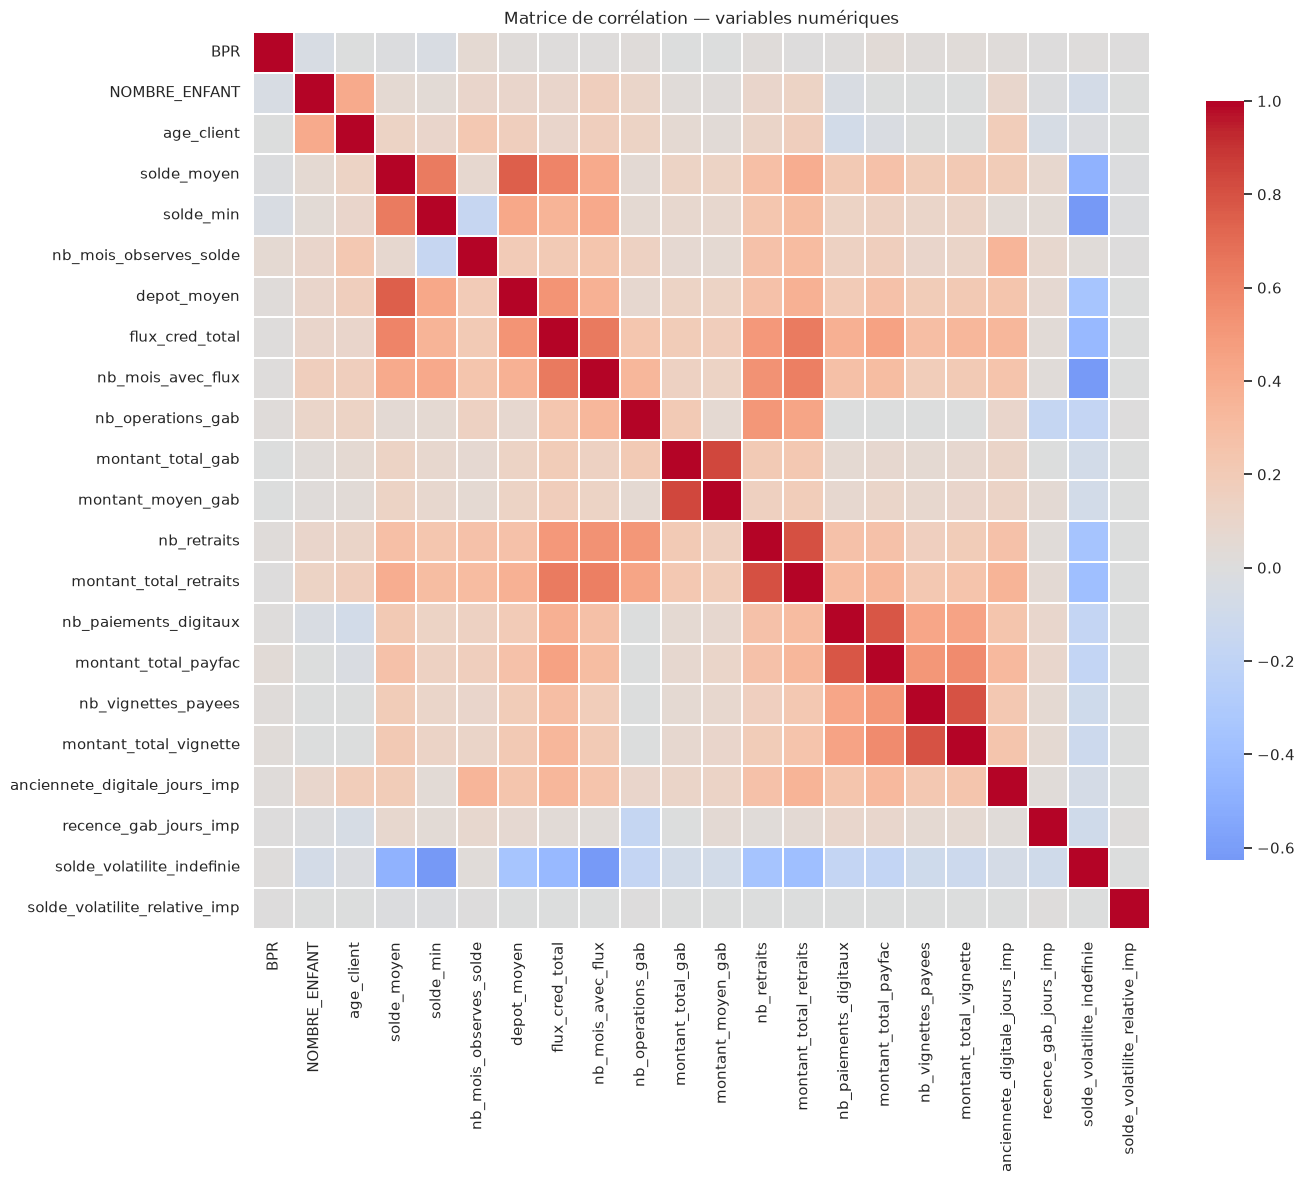

In [40]:
corr = df[real_num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.8}, linewidths=0.3)
ax.set_title("Matrice de corrélation — variables numériques")
plt.tight_layout()
plt.show()


In [41]:
# Paires de variables les plus corrélées (hors diagonale), en valeur absolue
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
)
corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
corr_pairs.sort_values("abs_corr", ascending=False).head(20)


,variable_1,variable_2,correlation,abs_corr
231,montant_total_gab,montant_moyen_gab,0.839217,0.839217
277,nb_retraits,montant_total_retraits,0.805123,0.805123
369,nb_vignettes_payees,montant_total_vignette,0.797118,0.797118
323,nb_paiements_digitaux,montant_total_payfac,0.782232,0.782232
72,solde_moyen,depot_moyen,0.747270,0.747270
162,flux_cred_total,nb_mois_avec_flux,0.638965,0.638965
167,flux_cred_total,montant_total_retraits,0.637655,0.637655
70,solde_moyen,solde_min,0.633103,0.633103
108,solde_min,solde_volatilite_indefinie,-0.626356,0.626356
196,nb_mois_avec_flux,solde_volatilite_indefinie,-0.619729,0.619729


In [42]:
# Zoom : paires fortement corrélées (|r| > 0.7)
strong = corr_pairs[corr_pairs["abs_corr"] > 0.7].sort_values("abs_corr", ascending=False)
print(f"{len(strong)} paires avec |corrélation| > 0.7")
strong.drop(columns="abs_corr")


5 paires avec |corrélation| > 0.7


,variable_1,variable_2,correlation
231,montant_total_gab,montant_moyen_gab,0.839217
277,nb_retraits,montant_total_retraits,0.805123
369,nb_vignettes_payees,montant_total_vignette,0.797118
323,nb_paiements_digitaux,montant_total_payfac,0.782232
72,solde_moyen,depot_moyen,0.747270


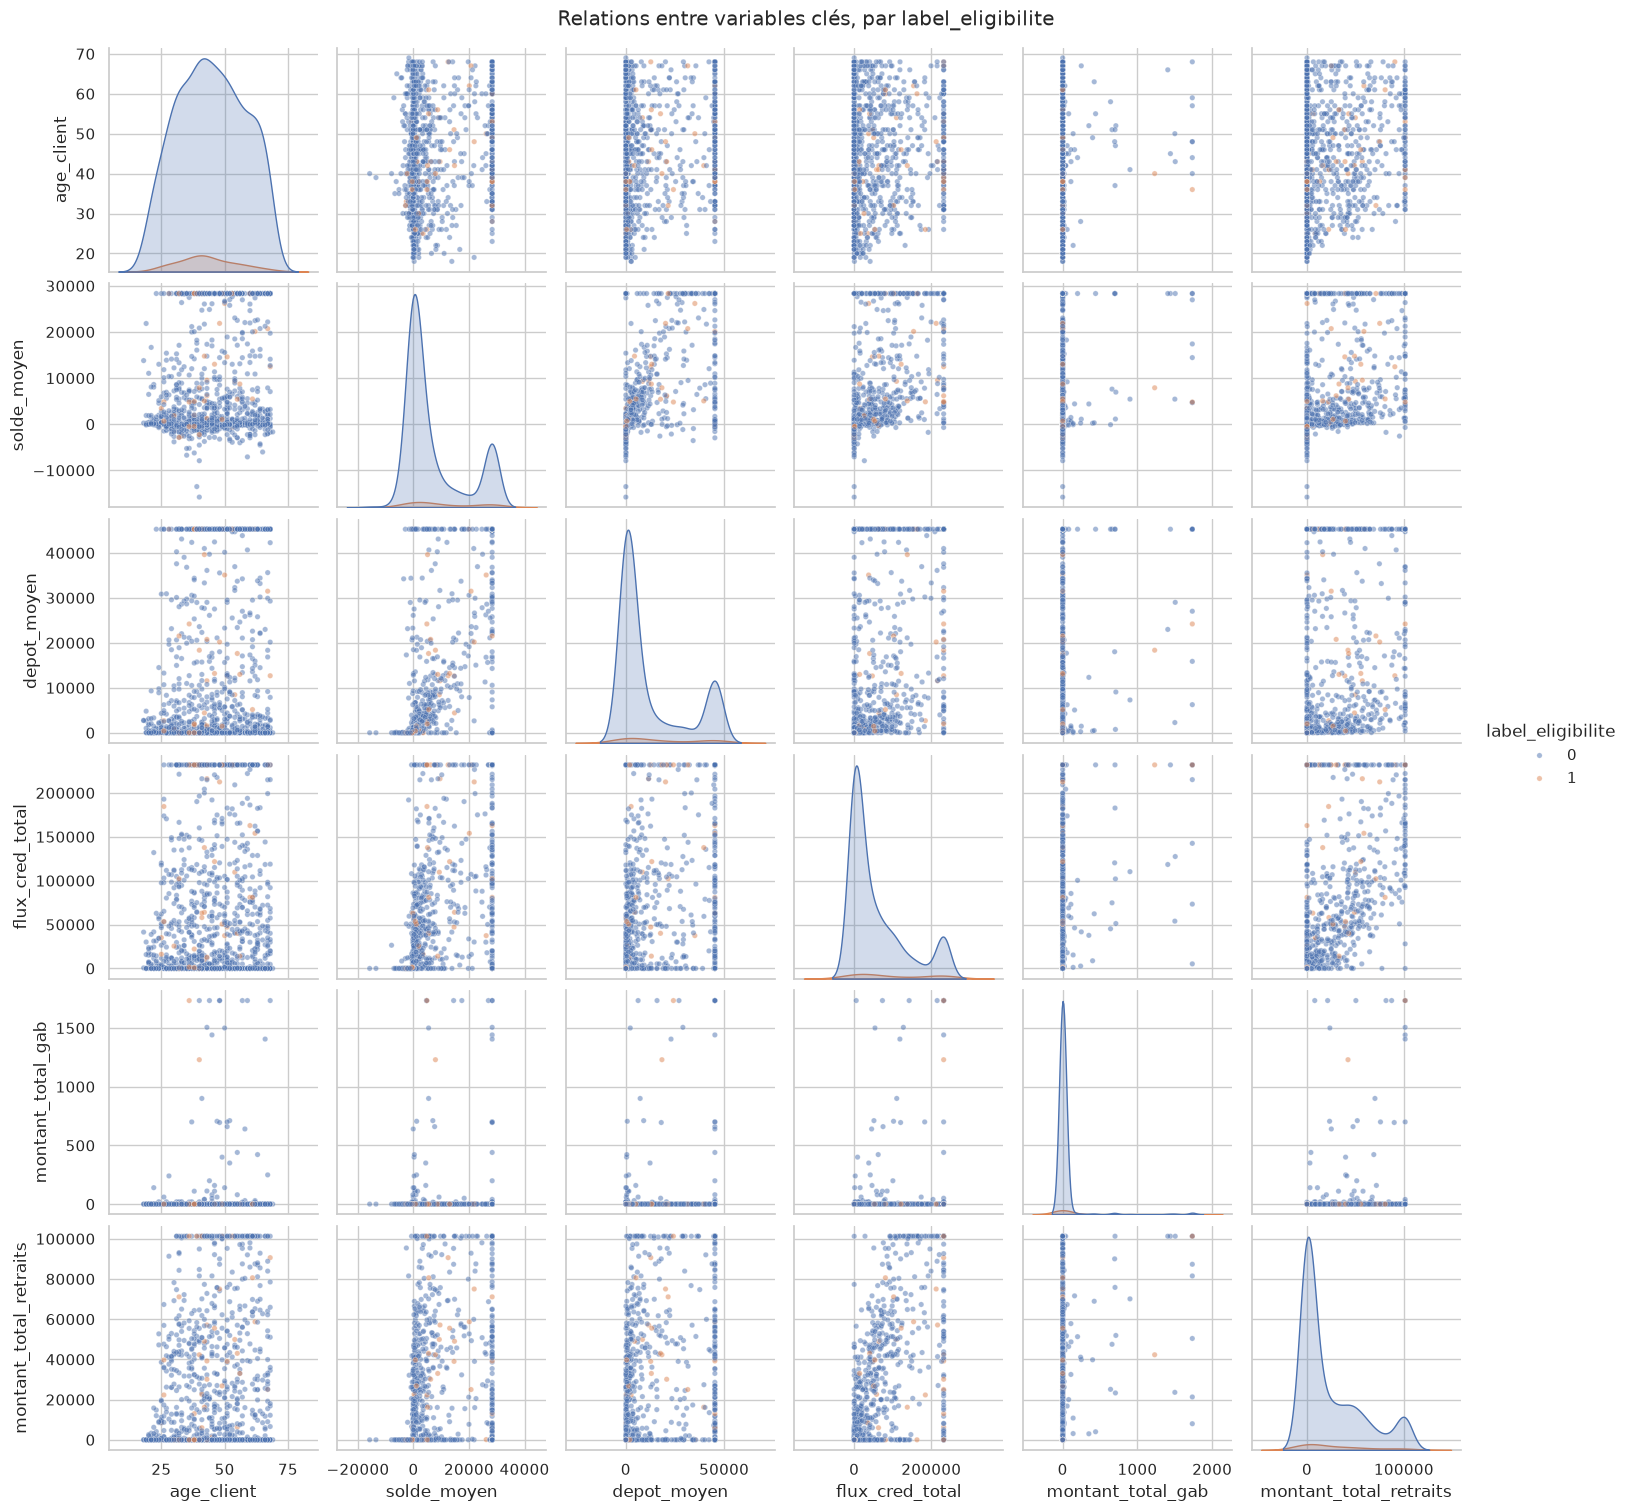

In [43]:
# Pairplot sur un sous-ensemble de variables clés (à adapter selon les besoins)
key_vars = ["age_client", "solde_moyen", "depot_moyen", "flux_cred_total",
            "montant_total_gab", "montant_total_retraits"]
key_vars = [c for c in key_vars if c in df.columns]

sns.pairplot(df[key_vars + [COL_CIBLE]].sample(min(1000, len(df)), random_state=42),
             hue=COL_CIBLE, diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle(f"Relations entre variables clés, par {COL_CIBLE}", y=1.01)
plt.show()


## 8. Variables numériques vs. cible (`COL_CIBLE`)

Boxplots comparant la distribution de chaque variable numérique clé selon la classe cible
(`label_eligibilite` ou `label_nom` selon le `DATASET_CIBLE` en cours).

/tmp/ipykernel_295561/2846102747.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=COL_CIBLE, y=col, ax=ax, palette="deep", showfliers=False)
/tmp/ipykernel_295561/2846102747.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=COL_CIBLE, y=col, ax=ax, palette="deep", showfliers=False)
/tmp/ipykernel_295561/2846102747.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=COL_CIBLE, y=col, ax=ax, palette="deep", showfliers=False)
/tmp/ipykernel_295561/2846102747.py:15: FutureWarning: 

Passing `palette` with

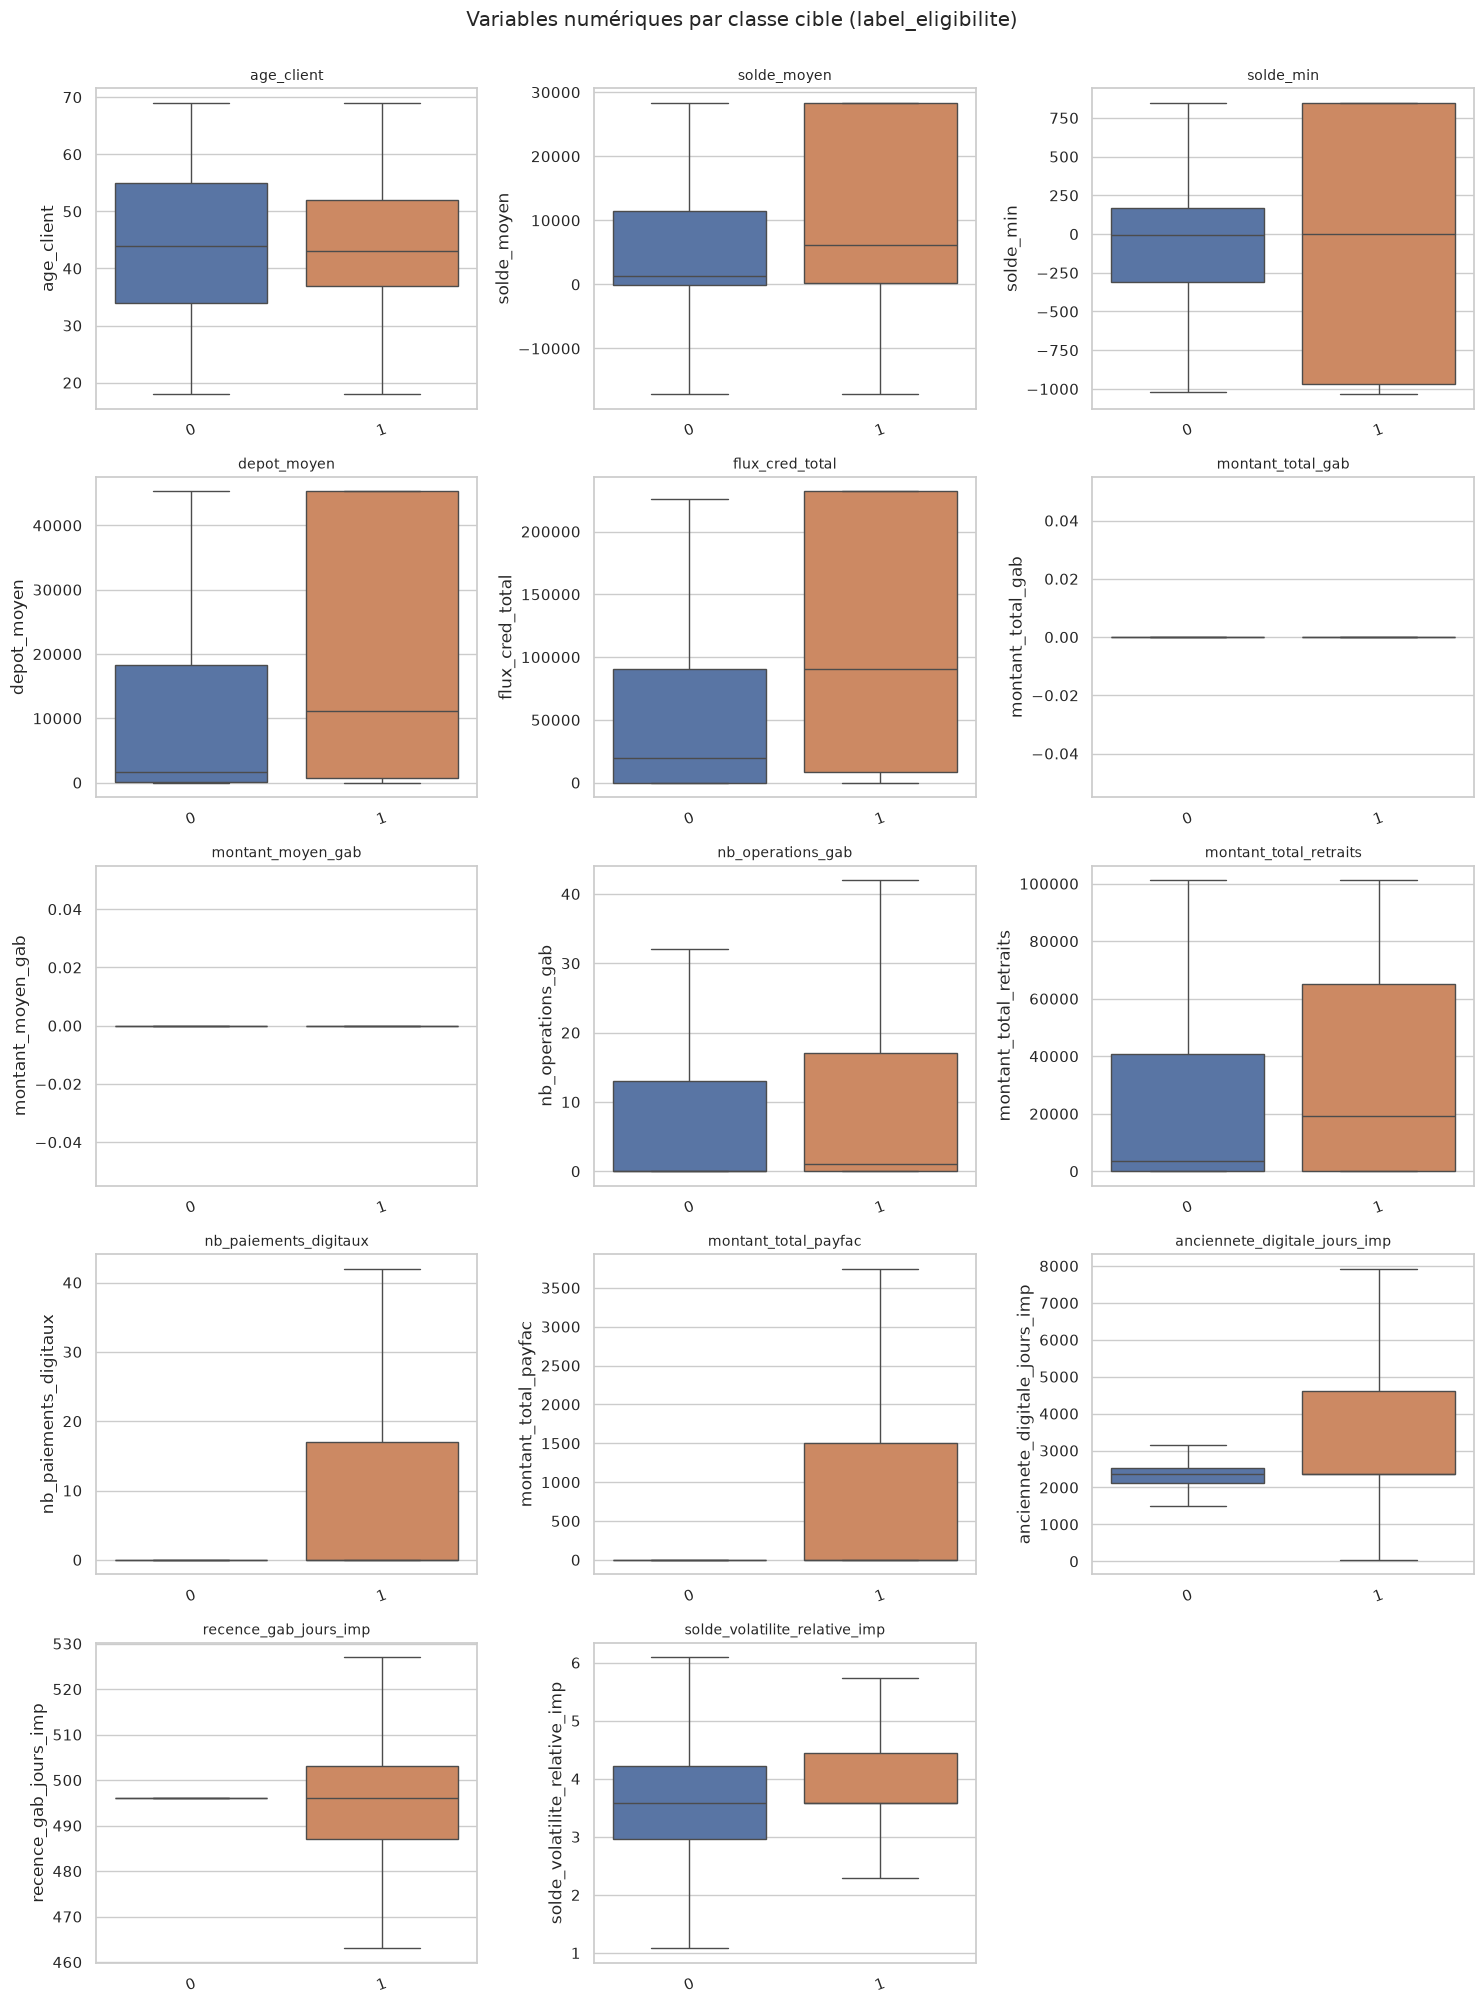

In [44]:
plot_vars = ["age_client", "solde_moyen", "solde_min", "depot_moyen", "flux_cred_total",
             "montant_total_gab", "montant_moyen_gab", "nb_operations_gab",
             "montant_total_retraits", "nb_paiements_digitaux", "montant_total_payfac",
             "anciennete_digitale_jours_imp", "recence_gab_jours_imp",
             "solde_volatilite_relative_imp"]
plot_vars = [c for c in plot_vars if c in real_num_cols]

ncols = 3
nrows = int(np.ceil(len(plot_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, col in enumerate(plot_vars):
    ax = axes[i]
    sns.boxplot(data=df, x=COL_CIBLE, y=col, ax=ax, palette="deep", showfliers=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Variables numériques par classe cible ({COL_CIBLE})", y=1.001)
plt.tight_layout()
plt.show()


In [45]:
# Moyennes par classe cible pour toutes les variables numériques continues
df.groupby(COL_CIBLE)[real_num_cols].mean().T


label_eligibilite,0,1
BPR,51.158343,52.080649
NOMBRE_ENFANT,0.624949,0.743321
age_client,44.193778,44.492634
solde_moyen,7100.063338,11135.632262
solde_min,-48.796113,-68.495723
nb_mois_observes_solde,23.014706,25.422222
depot_moyen,11766.234116,19659.937331
flux_cred_total,58043.731888,110468.474503
nb_mois_avec_flux,6.772856,8.984020
nb_operations_gab,19.341050,22.771036


## 9. Variables catégorielles vs. cible

Répartition de `COL_CIBLE` au sein de chaque modalité (pour les catégorielles à cardinalité
raisonnable).

In [46]:
low_card_cats = [c for c in cat_cols if df[c].nunique() <= 15]
print(low_card_cats)


['GENDER', 'MARITAL_STATUS', 'TAILLE_ENTREPRI', 'pack_etat']


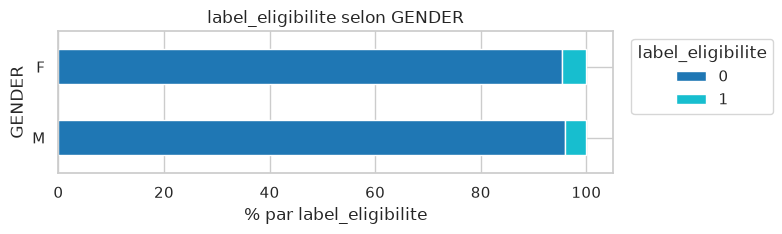

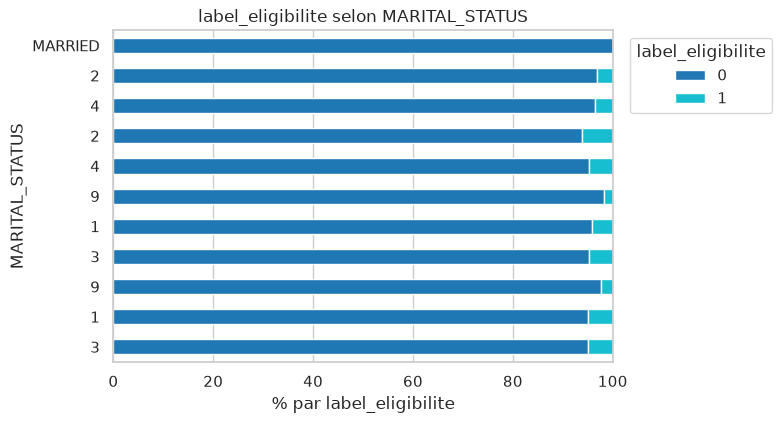

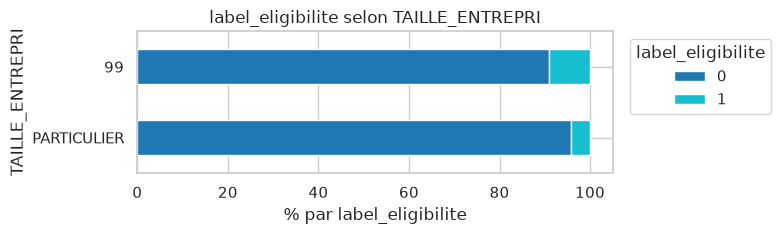

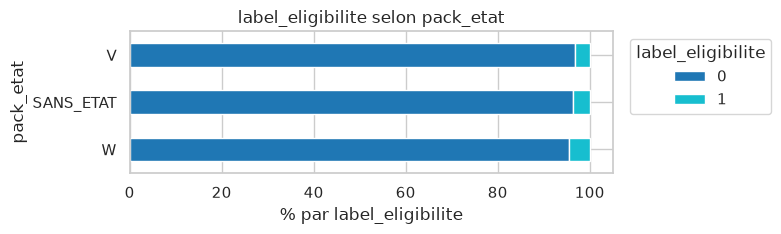

In [47]:
for col in low_card_cats:
    ct = pd.crosstab(df[col], df[COL_CIBLE], normalize="index") * 100
    ct = ct.loc[df[col].value_counts().index]  # trier par fréquence

    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.4*len(ct))))
    ct.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
    ax.set_xlabel(f"% par {COL_CIBLE}")
    ax.set_title(f"{COL_CIBLE} selon {col}")
    ax.legend(title=COL_CIBLE, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


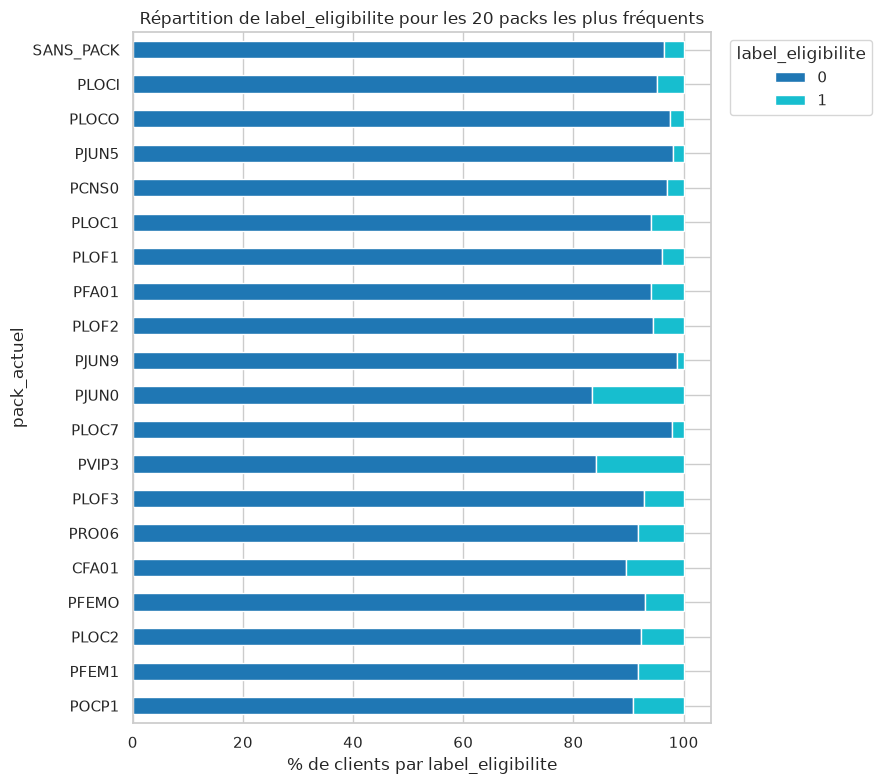

label_eligibilite,0,1
pack_actuel,,
SANS_PACK,96.5,3.5
PLOCI,95.2,4.8
PLOCO,97.6,2.4
PJUN5,98.0,2.0
PCNS0,97.0,3.0
PLOC1,94.1,5.9
PLOF1,96.0,4.0
PFA01,94.0,6.0
PLOF2,94.4,5.6


In [48]:
# pack_actuel a une cardinalité plus élevée (>15) -- traité à part, limité aux
# modalités les plus fréquentes plutôt qu'exclu entièrement de l'analyse vs. cible.
TOP_N_PACKS = 20
top_packs = df["pack_actuel"].value_counts().head(TOP_N_PACKS).index

ct_pack = pd.crosstab(df.loc[df["pack_actuel"].isin(top_packs), "pack_actuel"],
                       df[COL_CIBLE], normalize="index") * 100
ct_pack = ct_pack.loc[top_packs]

fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(ct_pack))))
ct_pack.plot(kind="barh", stacked=True, ax=ax, colormap="tab10")
ax.set_xlabel(f"% de clients par {COL_CIBLE}")
ax.set_ylabel("pack_actuel")
ax.set_title(f"Répartition de {COL_CIBLE} pour les {TOP_N_PACKS} packs les plus fréquents")
ax.legend(title=COL_CIBLE, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

ct_pack.round(1)


In [49]:
# Flags binaires vs cible : taux d'activation par classe
flag_by_target = df.groupby(COL_CIBLE)[flag_cols].mean().T * 100
flag_by_target


label_eligibilite,0,1
jamais_active_digital,44.852772,34.556804
jamais_utilise_gab,51.048499,46.966292
nb_mois_observes_solde_etait_extreme,7.681694,13.732834
solde_moyen_etait_extreme,15.518884,27.415730
solde_min_etait_extreme,35.151827,50.786517
solde_max_etait_extreme,13.266390,27.365793
depot_moyen_etait_extreme,16.087209,30.212235
flux_cred_moyen_etait_extreme,8.988075,27.041199
flux_cred_total_etait_extreme,9.133715,28.988764
montant_total_retraits_etait_extreme,6.780478,12.684145


## 10. Contrôles complémentaires

**CORRECTIF** : les 3 cellules suivantes appelaient des méthodes Spark (`df.filter(...)`,
`df.groupBy(...).count().toPandas()`) sur `df`, qui est un DataFrame **pandas** dans ce notebook
(chargé via `pd.read_csv` en section 1) — elles auraient levé une `AttributeError` à l'exécution.
Réécrites en pandas pur ci-dessous.

In [50]:
# Colonnes à variance nulle restantes -- sanity check après les correctifs de la Partie 1
# (section 5ter). Ne devrait plus rien remonter si le pipeline a bien tourné.
colonnes_constantes_restantes = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"Colonnes à variance nulle dans le CSV final : {colonnes_constantes_restantes or 'aucune'}")


Colonnes à variance nulle dans le CSV final : aucune


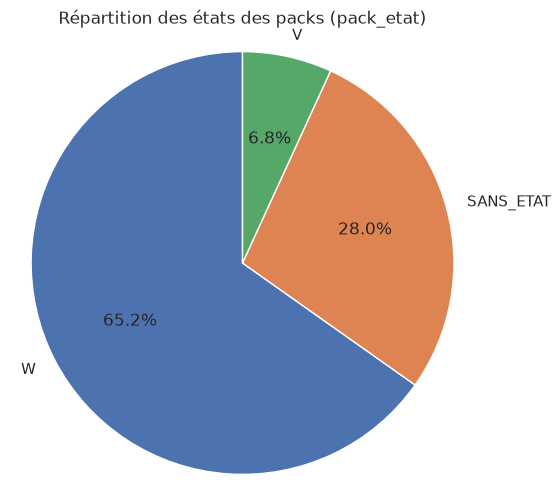

In [51]:
# Répartition de pack_etat (remplace l'appel Spark df.groupBy("pack_etat").count().toPandas())
counts = df["pack_etat"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Répartition des états des packs (pack_etat)")
plt.axis("equal")
plt.show()


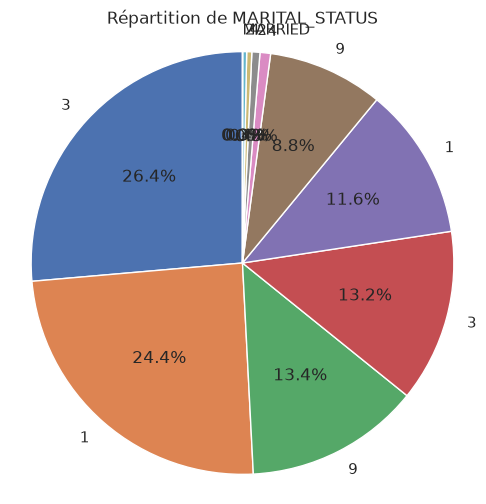

In [52]:
# Répartition de MARITAL_STATUS (remplace l'appel Spark équivalent)
# CORRECTIF : le titre était copié-collé de la cellule pack_etat ("États des packs")
# alors qu'il s'agit du statut marital -- corrigé.
counts = df["MARITAL_STATUS"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%", startangle=90)
plt.title("Répartition de MARITAL_STATUS")
plt.axis("equal")
plt.show()


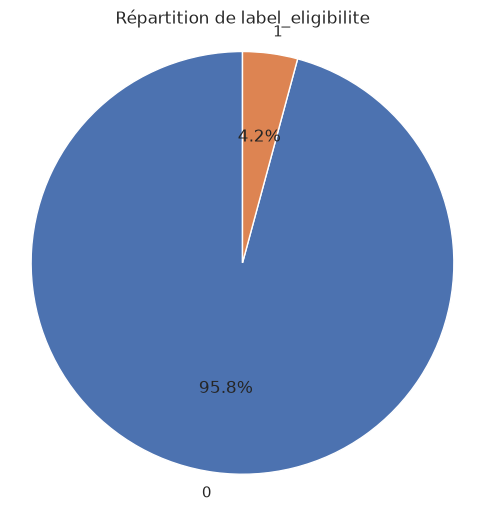

In [53]:
# df[df["label_eligibilite"]].count()
# Répartition de MARITAL_STATUS (remplace l'appel Spark équivalent)
# CORRECTIF : le titre était copié-collé de la cellule pack_etat ("États des packs")
# alors qu'il s'agit du statut marital -- corrigé.
counts = df["label_eligibilite"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index.astype(str), autopct="%1.1f%%", startangle=90)
plt.title("Répartition de label_eligibilite")
plt.axis("equal")
plt.show()


## 11. Synthèse

À compléter après lecture des graphiques ci-dessus. Points à vérifier systématiquement :

- **Qualité des données** : la cellule de section 2 doit remonter zéro colonne avec valeurs
  manquantes — sinon, une règle de nulls manque encore en Partie 1 (section 2).
- **Colonnes à variance nulle** : la cellule de section 10 doit remonter une liste vide — sinon,
  `identifier_colonnes_constantes` (Partie 1, section 5ter) ne couvre pas toutes les colonnes
  concernées et la liste `COLS_CATEGORIELLES_BASSE_CARDINALITE` doit être étendue.
- **Cardinalité extrême** : `CODE_VILLE` (haute cardinalité, ~270 modalités attendues) — confirmer
  qu'il reste traité en `StringIndexer` seul (pas de `OneHotEncoder`) au moment de construire le
  Pipeline MLlib (section 7, Partie 1).
- **Déséquilibre de classes** (section 3) : noter le ratio majoritaire/minoritaire de
  `COL_CIBLE` et décider dès maintenant de la stratégie (pondération de classes,
  sur/sous-échantillonnage -- Tomek Links uniquement sur `dataset_produit`, cf. guide section
  7.6bis --, métrique F1/AUC-PR ou BinaryClassificationEvaluator/MulticlassClassificationEvaluator
  selon le `DATASET_CIBLE`, plutôt qu'accuracy brute).
- **Variables les plus discriminantes** vis-à-vis de `COL_CIBLE` (sections 8 et 9) : lister les
  2-3 variables numériques et catégorielles dont la distribution varie le plus selon la classe --
  à comparer entre les deux passes (`eligibilite` vs `produit`), les variables discriminantes ne
  sont pas forcément les mêmes pour les deux questions.
- **Recadrage éligibilité/produit** (nouveau) : confirmer qu'aucune des deux passes ne contient de
  fuite -- `label_nom`/`label_code` absents de l'exploration `dataset_eligibilite`,
  `label_eligibilite` absent (ou constant si oublié) de l'exploration `dataset_produit`.
- **Paires fortement corrélées** (section 7, `|r| > 0.7`) : à surveiller pour la colinéarité,
  en gardant à l'esprit que `CODE_VILLE`/`BPR` n'y ont pas leur place (codes, pas des grandeurs).

*(Cette synthèse est un gabarit — elle doit être remplie avec les résultats réels une fois le
notebook exécuté sur le fichier `part-00000.parquet` complet ; aucun résultat n'est pré-rempli ici
car le dataset complet n'a pas été ré-exécuté dans cet environnement.)*